# Settings

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import scipy as sc
import scipy.stats as stats
import astropy.cosmology as ac
from matplotlib.patches import Ellipse
from matplotlib.gridspec import GridSpec
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numdifftools as nd
import pandas as pd
import sys
import astropy.constants as cst
import random
from matplotlib.patches import Patch
import zeus
from chainconsumer import ChainConsumer
from tqdm import tqdm
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from astropy.io import fits
from tqdm.notebook import tqdm
from IPython.display import display, Markdown, Math
from matplotlib import colors

In [3]:
import fisher_matrix_analysis as fma
import basket as ba

In [4]:
# figure size setting for article

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "dejavuserif",
    "font.size": 11,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "font.sans-serif": "Computer Modern lsst",
    "figure.dpi": 300,
    "figure.figsize": (6.1,4.6),  # Put your journal width here
    "savefig.bbox": "tight"})

# 1. lsst mock data

In [5]:
# define cosmological parameters
H0_fid=73
Mb_fid=-19.3
c=float(np.array(cst.c.to('km/s')))


#for flat LCDM, according to Planck 2018 (TT,TE,EE+lowE+lensing)
Om0_fLCDM = 0.3153
Ode0_fLCDM = 1-Om0_fLCDM

#for LCDM
Om0_kLCDM, Ode0_kLCDM = 0.3153, 0.6
Ok0_kLCDM = 1-Om0_kLCDM-Ode0_kLCDM

#for flat wCDM
Om0_fwCDM, w0_fwCDM = 0.3153, -1.029

#for k-wCDM
Om0_kwCDM, Ode0_kwCDM, w0_kwCDM =  0.3153, 0.6, -1.029

#for flat CPL
Om0_fCPL, w0_fCPL, wa_fCPL = 0.3153, -1.029, 0.21

#for CPL
Om0_kCPL, Ode0_kCPL, w0_kCPL, wa_kCPL = 0.3153, 0.6, -1.029, 0.21

#for PEDE
Om0_PEDE, Ode0_PEDE = 0.3153, 0.6
Ok0_PEDE=1-Om0_PEDE-Ode0_PEDE

fiducial_fLCDM  = [Om0_fLCDM,Mb_fid]

fiducial_kLCDM = [Om0_kLCDM, Ode0_kLCDM, Mb_fid]


fiducial_fwCDM = [Om0_fwCDM, w0_fwCDM, Mb_fid]

fiducial_kwCDM = [Om0_kwCDM, Ode0_kwCDM, w0_kwCDM,Mb_fid]

fiducial_fCPL=[Om0_fCPL,w0_fCPL,wa_fCPL,Mb_fid]
 
# fiducial cosmologie
#LCDM
cosmo_fLCDM = ac.FlatLambdaCDM(H0=H0_fid,Om0=Om0_fLCDM)
cosmo_kLCDM = ac.LambdaCDM(H0=H0_fid,Om0=Om0_fLCDM,Ode0=Ode0_fLCDM)

#wCDM
cosmo_fwCDM = ac.FlatwCDM(H0=H0_fid,Om0=Om0_fLCDM,w0=w0_fwCDM)
cosmo_kwCDM = ac.wCDM(H0=H0_fid,Om0=Om0_kwCDM,Ode0=Ode0_kwCDM,w0=w0_kwCDM)

#CPL
cosmo_fCPL=ac.Flatw0waCDM(H0=H0_fid,Om0=Om0_fCPL,w0=w0_fCPL,wa=wa_fCPL)

In [6]:
# lsst data

lsst = pd.read_table('lsst_data/lsst_snIa_data.csv',sep=',')
z_lsst=np.array(lsst.zHEL)
mu_lsst=np.array(lsst.MU)
dist_lsst=lsst.N

# statistical error
sigma_stat=lsst.MUERR
rho = 0
std_matrix =  np.diag(sigma_stat)
corr_matrix = np.full((len(sigma_stat),len(sigma_stat)),rho)
np.fill_diagonal(corr_matrix,1.0)
Cov_lsst_stat = std_matrix @ corr_matrix @ std_matrix

# systematic error
Cov_lsst_sys=np.array(pd.read_table('lsst_data/covsys_lsst.csv',sep=',')).reshape((len(z_lsst),len(z_lsst))) 

# total covariance matrix
Cov_lsst = Cov_lsst_sys + Cov_lsst_stat
Cov_inv_lsst=np.linalg.inv(Cov_lsst)

# define bin edges
edges_mid = 0.5 * (z_lsst[1:] + z_lsst[:-1])
# first and last edges
first_edge = z_lsst[0] - (edges_mid[0] - z_lsst[0])
last_edge  = z_lsst[-1] + (z_lsst[-1] - edges_mid[-1])

# combine
z_edges = np.concatenate([[first_edge], edges_mid, [last_edge]])

In [7]:
fma.is_positive_definite(Cov_lsst)

True

In [8]:
fma.is_positive_definite(Cov_lsst_stat), fma.is_positive_definite(Cov_lsst)

(True, True)

In [9]:
# Mock noisy data
mock_lsst = np.load('lsst_data/LSST_fLCDM.npz')
mb_lsst = mock_lsst['mb']

In [10]:
# lsst cost
tt = ba.T_lsst(z_lsst)
tt.shape

(14,)

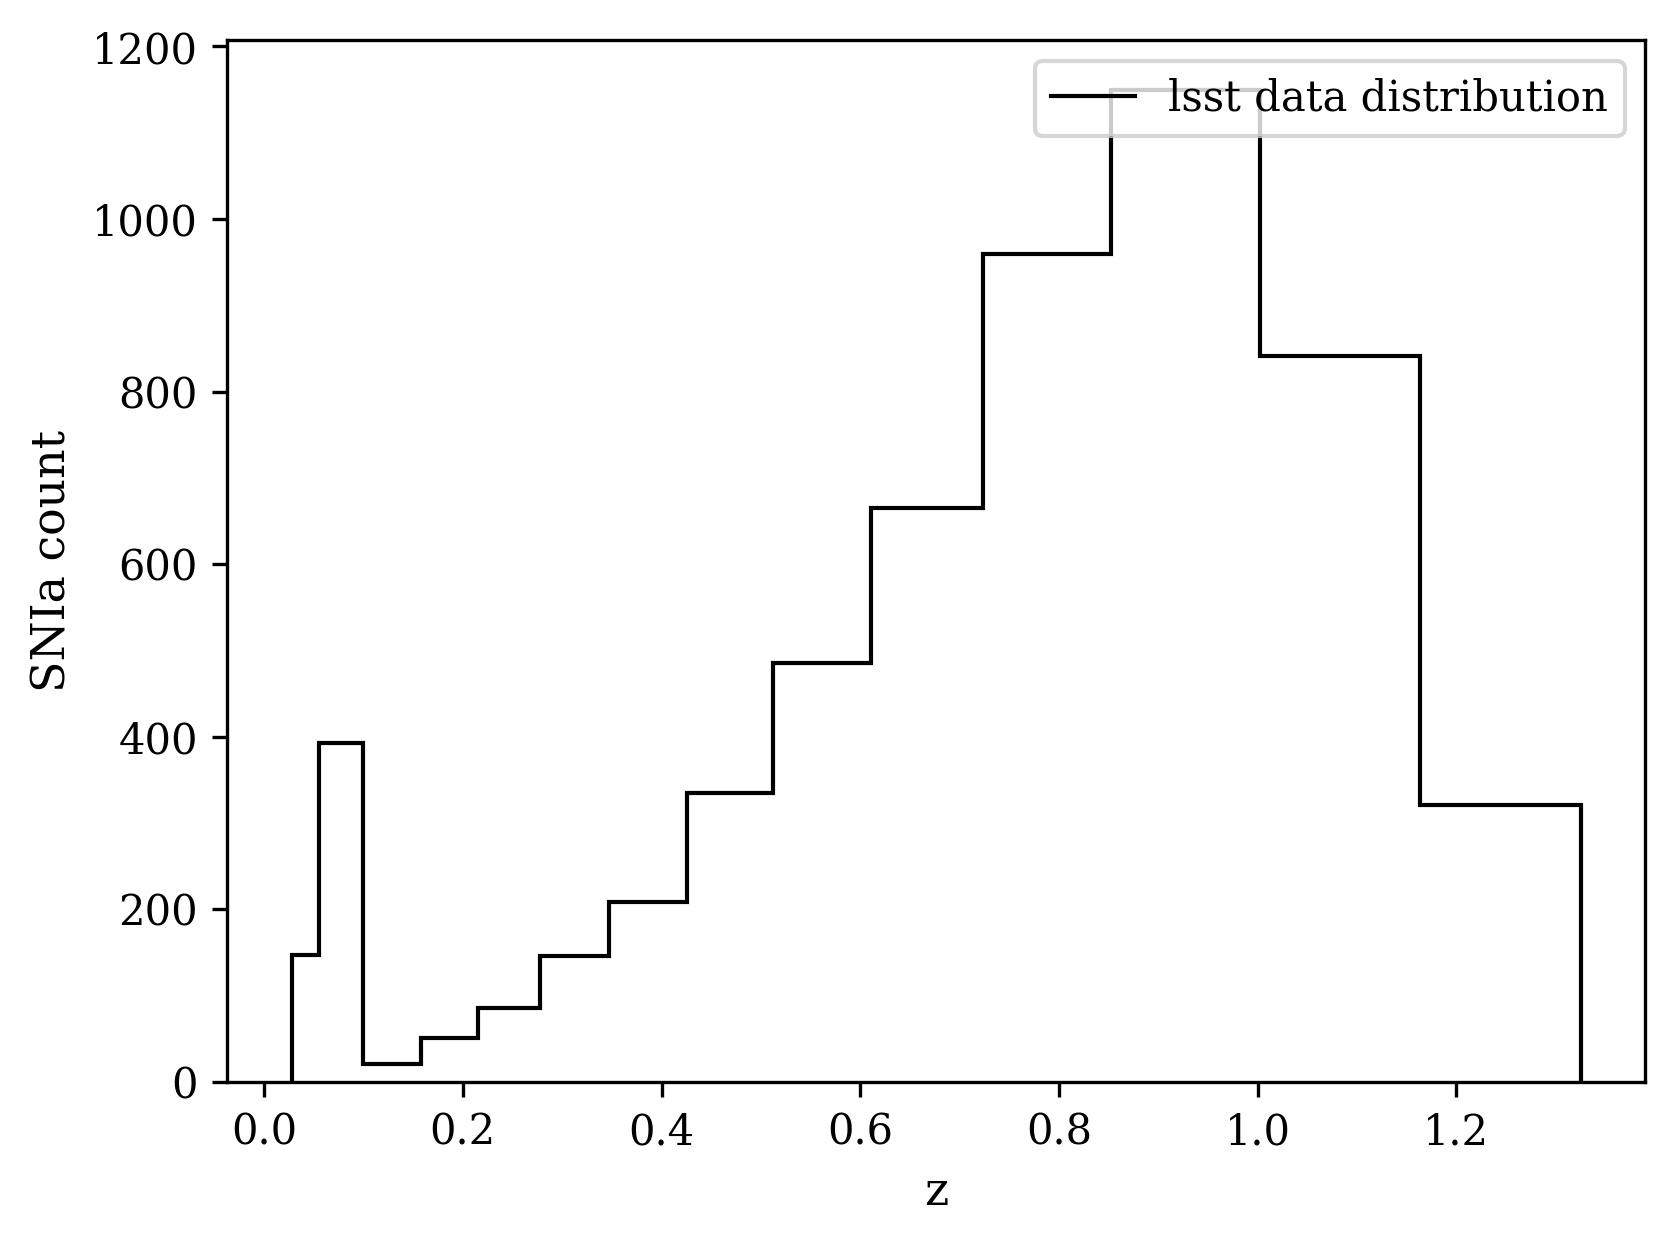

In [11]:
# Estimate bin edges

# plot
plt.stairs(dist_lsst, z_edges, label="lsst data distribution", color="black")
plt.xlabel("z")
plt.ylabel("SNIa count")
plt.legend(loc='upper right')
#plt.savefig("figures/lsst_data_distribution")
plt.show()

In [12]:
obs_time_lsst = (dist_lsst * tt).sum()

display(Markdown(rf"""
<div style="border:1px solid #999; padding:10px; border-radius:6px">

**lsst Survey Data Overview**

- Total number of Type Ia supernovae: {dist_lsst.sum():,.0f} 
- Total number of bins: {len(z_lsst)}  
- Redshift range: ${z_lsst.min():.3f} \leq z \leq {z_lsst.max():.3f}$  
- Total observation time: {obs_time_lsst/(3600*24):.2f} days  
- Mean error on $m_\mathrm{{B}}$: {np.sqrt(np.diag(Cov_lsst)).mean():.2f}  

</div>
"""))


<div style="border:1px solid #999; padding:10px; border-radius:6px">

**lsst Survey Data Overview**

- Total number of Type Ia supernovae: 5,809 
- Total number of bins: 14  
- Redshift range: $0.041 \leq z \leq 1.244$  
- Total observation time: 10.25 days  
- Mean error on $m_\mathrm{B}$: 0.01  

</div>


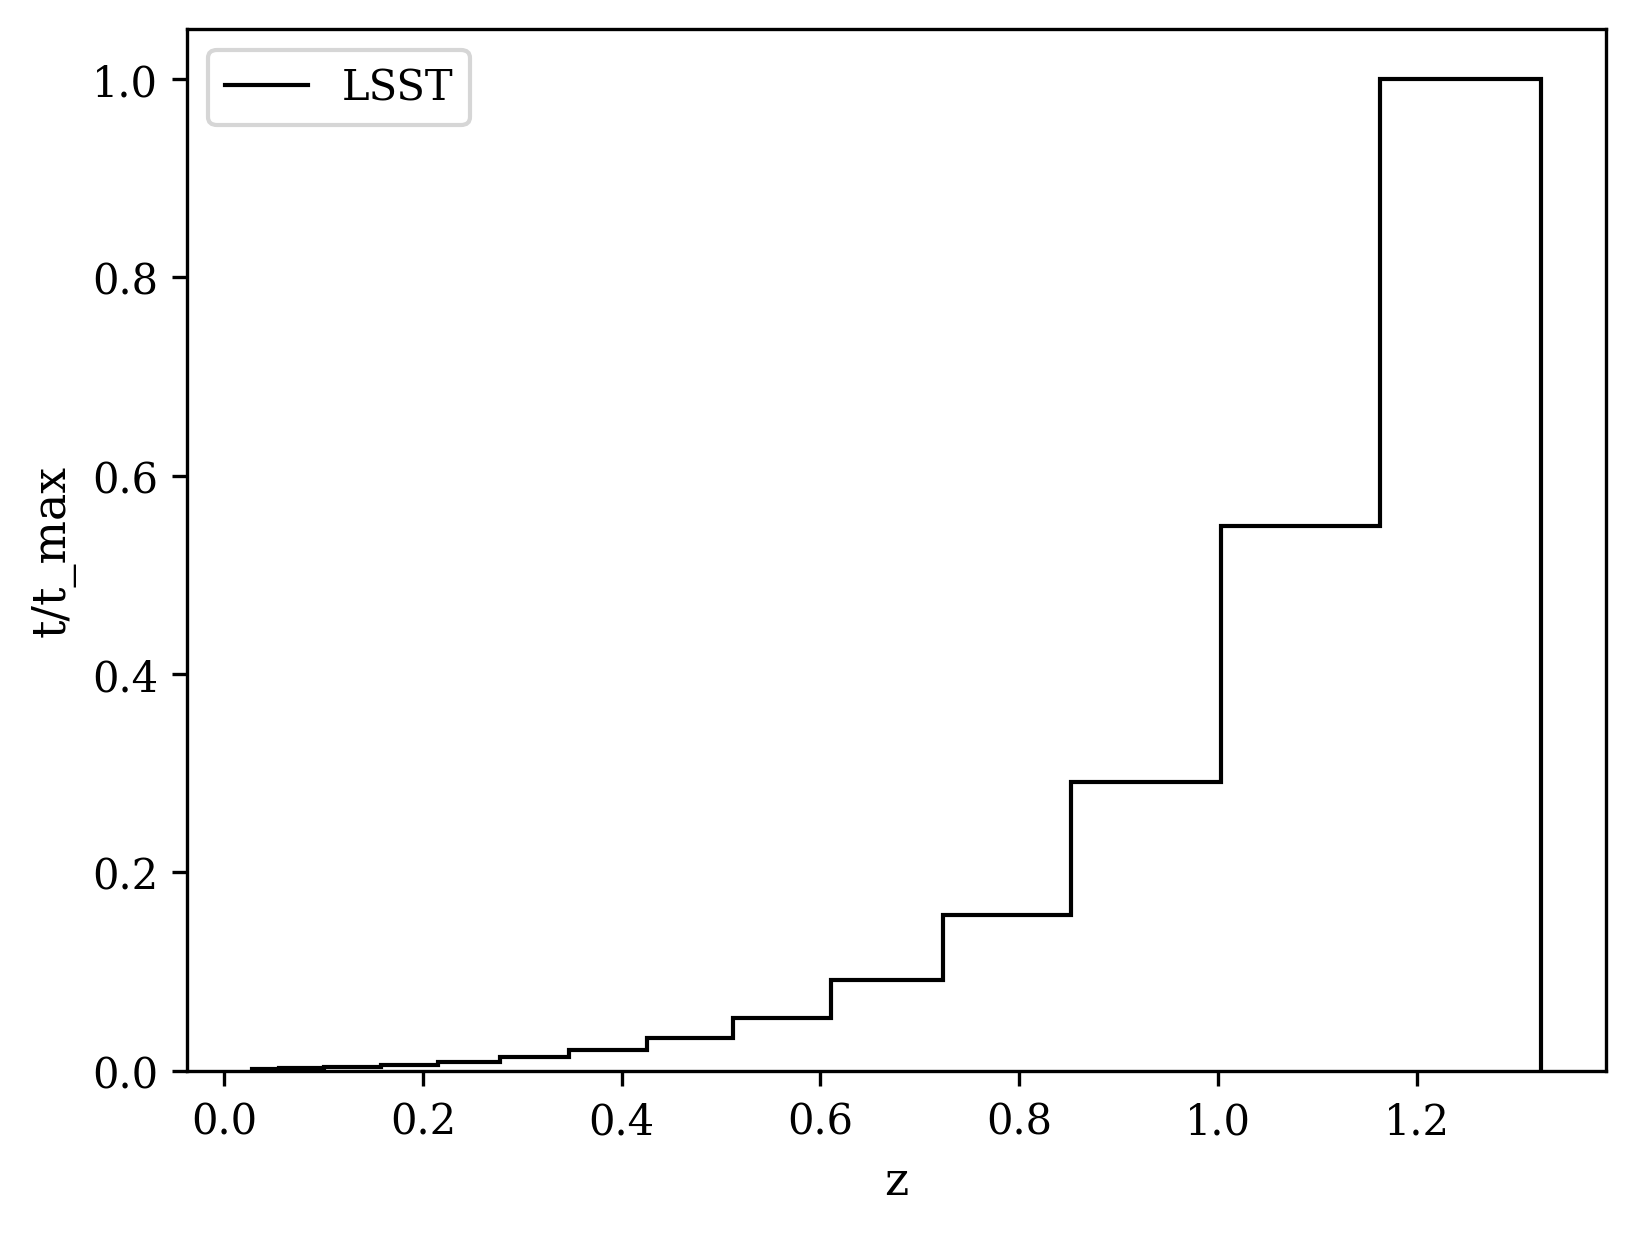

In [13]:
tt_in_hour = tt/3600


plt.stairs(tt/tt[-1], z_edges, label="LSST", color="black")
plt.xlabel("z")
plt.ylabel("t/t_max")
plt.legend(loc='upper left')
#plt.savefig('figures/lsst_observation_time')
plt.show()

# 2. Optimisation

In [14]:
cosmo = cosmo_fLCDM
cosmo_name = 'fLCDM'
fiducial_cosmo = fiducial_fLCDM

In [15]:
# fix H0, vary Mb
H0 = ac.WMAP9.H0

In [16]:
num_params=len(fiducial_cosmo)
h = np.full(num_params, 1e-5)

In [17]:
z_lsst.shape, mb_lsst.shape, Cov_lsst.shape

((14,), (14,), (14, 14))

In [18]:
fiducial_cosmo, cosmo_name,

([0.3153, -19.3], 'fLCDM')

In [19]:
FF = fma.fisher_matrix_fd(fma.chi2, fiducial_cosmo, cosmo_name, H0, z_lsst, mb_lsst, Cov_lsst,h=h)
FF

array([[ 279698.91164048, -253186.4993216 ],
       [-253186.4993216 ,  291123.36505932]])

In [20]:
fma.is_positive_definite(FF)

True

In [21]:
np.linalg.eigh(FF)[0]

array([ 32160.2094815, 538662.0672183])

In [22]:
II = np.eye(FF.shape[0])
CC = np.linalg.solve(FF, II)
CC

array([[1.68051271e-05, 1.46152175e-05],
       [1.46152175e-05, 1.61456493e-05]])

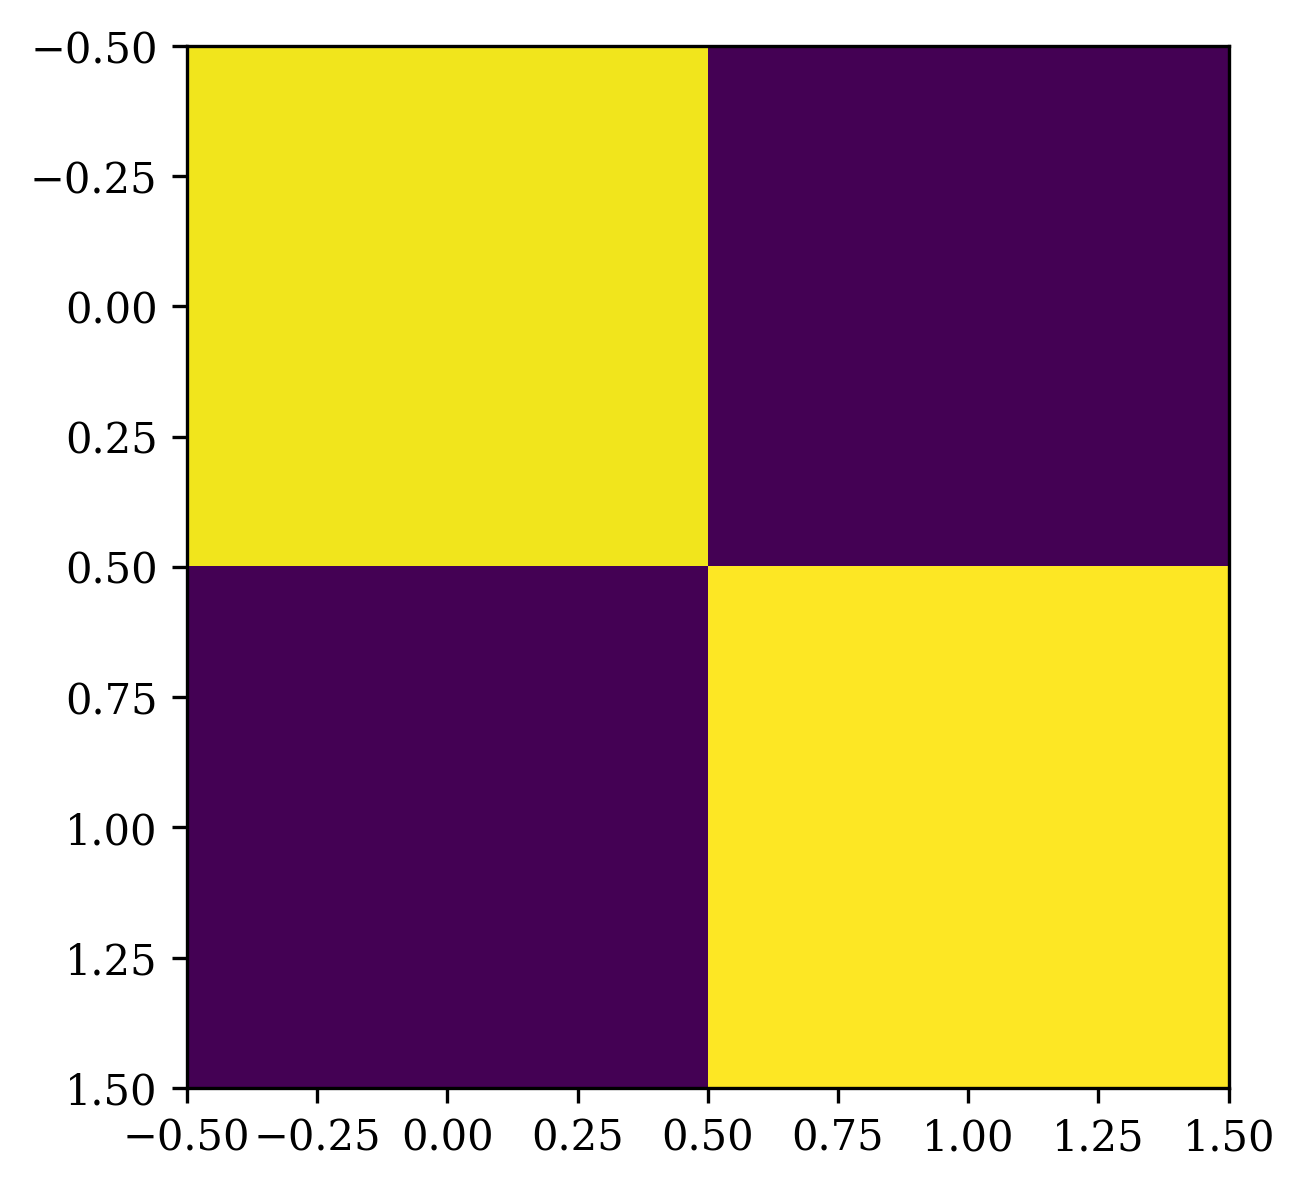

In [23]:
plt.imshow(FF)

In [24]:
fma.is_positive_definite(CC)

True

In [25]:
# CC_sub = fma.marginalize_fisher_matrix(FF, ('Om0','Ode0'), ['Om0', 'Ode0', 'Mb'])

In [26]:
AA = fma.ellipse_parameters(CC, 0.32)[3] #area
FOM = 1/AA

$$
\mathrm{FoM} = \frac{1}{\pi \, \Delta\chi^2 \, \sqrt{\det \mathbf{C}}}
$$

At 68% confidence level, $\Delta\chi^2 \simeq 2.279$.

In [27]:
FOM, 1/(np.pi * sc.stats.chi2.ppf(0.68, df=2) * np.sqrt(np.linalg.det(CC)))

(18384.358509355785, 18384.358509355807)

In [28]:
AA

5.4394065449229615e-05

In [29]:
T0 = (dist_lsst*tt).sum()
T0

885854.865537058

In [31]:
nb_iter = 100
perturbation = 1 # it is first-order, linear optimisation, so keep the perturbation very small

# ----------------- INITIALISATION----------------- 
ss=len(fiducial_fLCDM) #nb of param

track_ellipse = np.zeros((nb_iter,4))
track_FF = np.zeros((nb_iter,ss,ss))
track_distribution = np.zeros((nb_iter,dist_lsst.shape[0]))
track_delta_n = np.zeros((nb_iter,dist_lsst.shape[0]))
track_Cov = np.zeros((nb_iter,Cov_lsst.shape[0],Cov_lsst.shape[1]))
track_dFOM = np.zeros((nb_iter,len(z_lsst)))
track_kk = np.zeros((nb_iter))


# lsst distribution
dist_reference = np.copy(dist_lsst).astype(float) # initialised to original lsst distribution
Cov_reference = np.copy(Cov_lsst)
Cov_stat_reference = Cov_lsst_stat
Cov_sys = Cov_lsst_sys
FOM_reference = np.copy(FOM)


pbar = tqdm(range(nb_iter), desc="Optimizing bins")
for nn in pbar:

    #---------------------- GRADIENT ----------------------

    dFOM = np.zeros_like(z_lsst)

    for i in range(0,len(z_lsst)):

        # copy unperturbed distribution
        dist_perturbed = np.copy(dist_reference)
        
        # IL FALLAIT L'AJOUTER BANANE
        dist_perturbed[i] += perturbation

        # FOM perturbed 
        DDp = np.diag(np.sqrt(dist_reference/dist_perturbed))

        # modify stat and sys separately
        Cov_stat_perturbed = DDp @ Cov_stat_reference @ DDp
        Cov_perturbed = Cov_stat_perturbed + Cov_sys

        #modify both together
        #Cov_perturbed = DDp @ Cov_reference @ DDp

        FF_perturbed = fma.fisher_matrix_fd(fma.chi2, 
                                         fiducial_fLCDM, 
                                         'fLCDM', 
                                         H0, 
                                         z_lsst, 
                                         mb_lsst, 
                                         Cov_perturbed)
        
        track_FF[nn]=FF_perturbed

        # if no marginalisation
        CC_perturbed = np.linalg.inv(FF_perturbed)

        # if marginalisation
        # CC_perturbed = fma.marginalize_fisher_matrix(FF_perturbed, ('Om0','Ode0'), ['Om0', 'Ode0', 'Mb'])
        
        track_ellipse[nn] = fma.ellipse_parameters(CC_perturbed, 0.32)
        FOM_perturbed = 1/track_ellipse[nn][3]

        # update array of dFOM
        dFOM[i] = (FOM_perturbed - FOM_reference) / tt[i]

        # loop, dist_perturbed become a copy of the reference distribution again, and the perturbation move onto the next bin
    
    # find bin with lowest dFOM
    kk = dFOM.argmin()
    track_kk[nn] = kk
    track_dFOM[nn] = dFOM
    
    # # Find bins with negative dFOM
    # gg = np.where(dFOM > 0)[0]

    # # array of bins to ignore in the re-allocation
    
    # ignore = np.unique(np.sort(np.append(gg, kk)))
    # print(ignore)

    #---------------------- REMOVE SYSTEM ----------------------

    # first, define the new distribution as a copy of the reference distribution
    dist_new = np.copy(dist_reference) 

    # remove 1 system in this bin, but keep it >= 1
    if dist_new[kk] > perturbation:
        dist_new[kk] -= perturbation
     

        # time saved 
        time_saved = tt[kk] * perturbation

        #---------------------- TIME REALLOCATION ----------------------

        delta_n  = np.zeros_like(z_lsst) # define correction to the number of systems in each bin to re-allocate the saved time
        
        # compute it
        # denom = dFOM.sum() - dFOM[ignore].sum()
        denom = dFOM.sum() - dFOM[kk]
        for j in range(0,len(z_lsst)):
            # if j not in ignore: 
            if j!=kk: # important: on exclut le redshift bin dans lequel on a retiré le sytème
                delta_n[j] = perturbation * tt[kk]/tt[j] * dFOM[j]/denom
                dist_new[j] = max(dist_new[j] + delta_n[j], 1e-8)
    

        # print('Time saved:',time_saved,'s')
        # print('Time re-allocated', (delta_n*tt).sum(),'s')

        if (dist_new <= 0).any():
            print(f"Zero detected at iteration {nn}")
            print(dist_new)
            break
        
        DD = np.diag(np.sqrt(dist_reference/dist_new))
        Cov_stat_new = DD @ Cov_stat_reference @ DD

        if fma.is_positive_definite(Cov_stat_new) != True:
            print('Cov_stat is non PSD at iter', nn)

        Cov_new = Cov_stat_new + Cov_sys
        #Cov_new = DD @ Cov_reference @ DD

        if fma.is_positive_definite(Cov_new) != True:
            print('Cov is non PSD at iter', nn)

        FF_new = fma.fisher_matrix_fd(fma.chi2, 
                                fiducial_fLCDM, 
                                'fLCDM', 
                                H0, 
                                z_lsst, 
                                mb_lsst, 
                                Cov_new)
        CC_new = np.linalg.inv(FF_new)
        #CC_new = fma.marginalize_fisher_matrix(FF_new, ('Om0','Ode0'), ['Om0', 'Ode0', 'Mb'])
        FOM_new = 1/fma.ellipse_parameters(CC_new, 0.32)[3]
        #print('Optimisation worked:',FOM_new>FOM_reference)

        track_delta_n[nn] = delta_n
        track_distribution[nn] = dist_new
        track_Cov[nn] = Cov_new

        #---------------------- PREPARATION FOR NEXT ITERATION ----------------------
        
        dist_reference = dist_new
        Cov_reference = Cov_new
        # Cov_stat_reference = Cov_stat_new
        FOM_reference = FOM_new
        
    else:
        continue
optimized_dist = np.round(dist_new).astype('int64')

Optimizing bins:   0%|          | 0/100 [00:00<?, ?it/s]

In [88]:
save_as = "optimization_tracks_lsst_1000.npz"
np.savez_compressed(
    save_as,
    track_ellipse=track_ellipse,
    track_FF=track_FF,
    track_distribution=track_distribution,
    track_delta_n=track_delta_n,
    track_Cov=track_Cov,
    track_dFOM=track_dFOM
)

print("All tracking arrays saved to", save_as)

All tracking arrays saved to optimization_tracks_lsst_1000.npz


In [73]:
track_data = np.load("optimization_tracks_lsst_1000.npz")

track_ellipse = track_data["track_ellipse"]
track_FF = track_data["track_FF"]
track_distribution = track_data["track_distribution"]
track_delta_n = track_data["track_delta_n"]
track_Cov = track_data["track_Cov"]
track_dFOM = track_data["track_dFOM"]

print("All tracking arrays successfully loaded")

All tracking arrays successfully loaded


In [74]:
obs_time_opt = (optimized_dist*tt).sum()
print('Original observation time:', obs_time_lsst)
print('Observation time after optimization', obs_time_opt)
print('Observation time ratio:', obs_time_opt/obs_time_lsst)

Original observation time: 885854.865537058
Observation time after optimization 886174.5558046041
Observation time ratio: 1.0003608833455493


In [75]:
print('area ratio new/ref', track_ellipse[-1][3]/AA)

area ratio new/ref 0.9996511719178998


Text(0, 0.5, 'cosmological leverage')

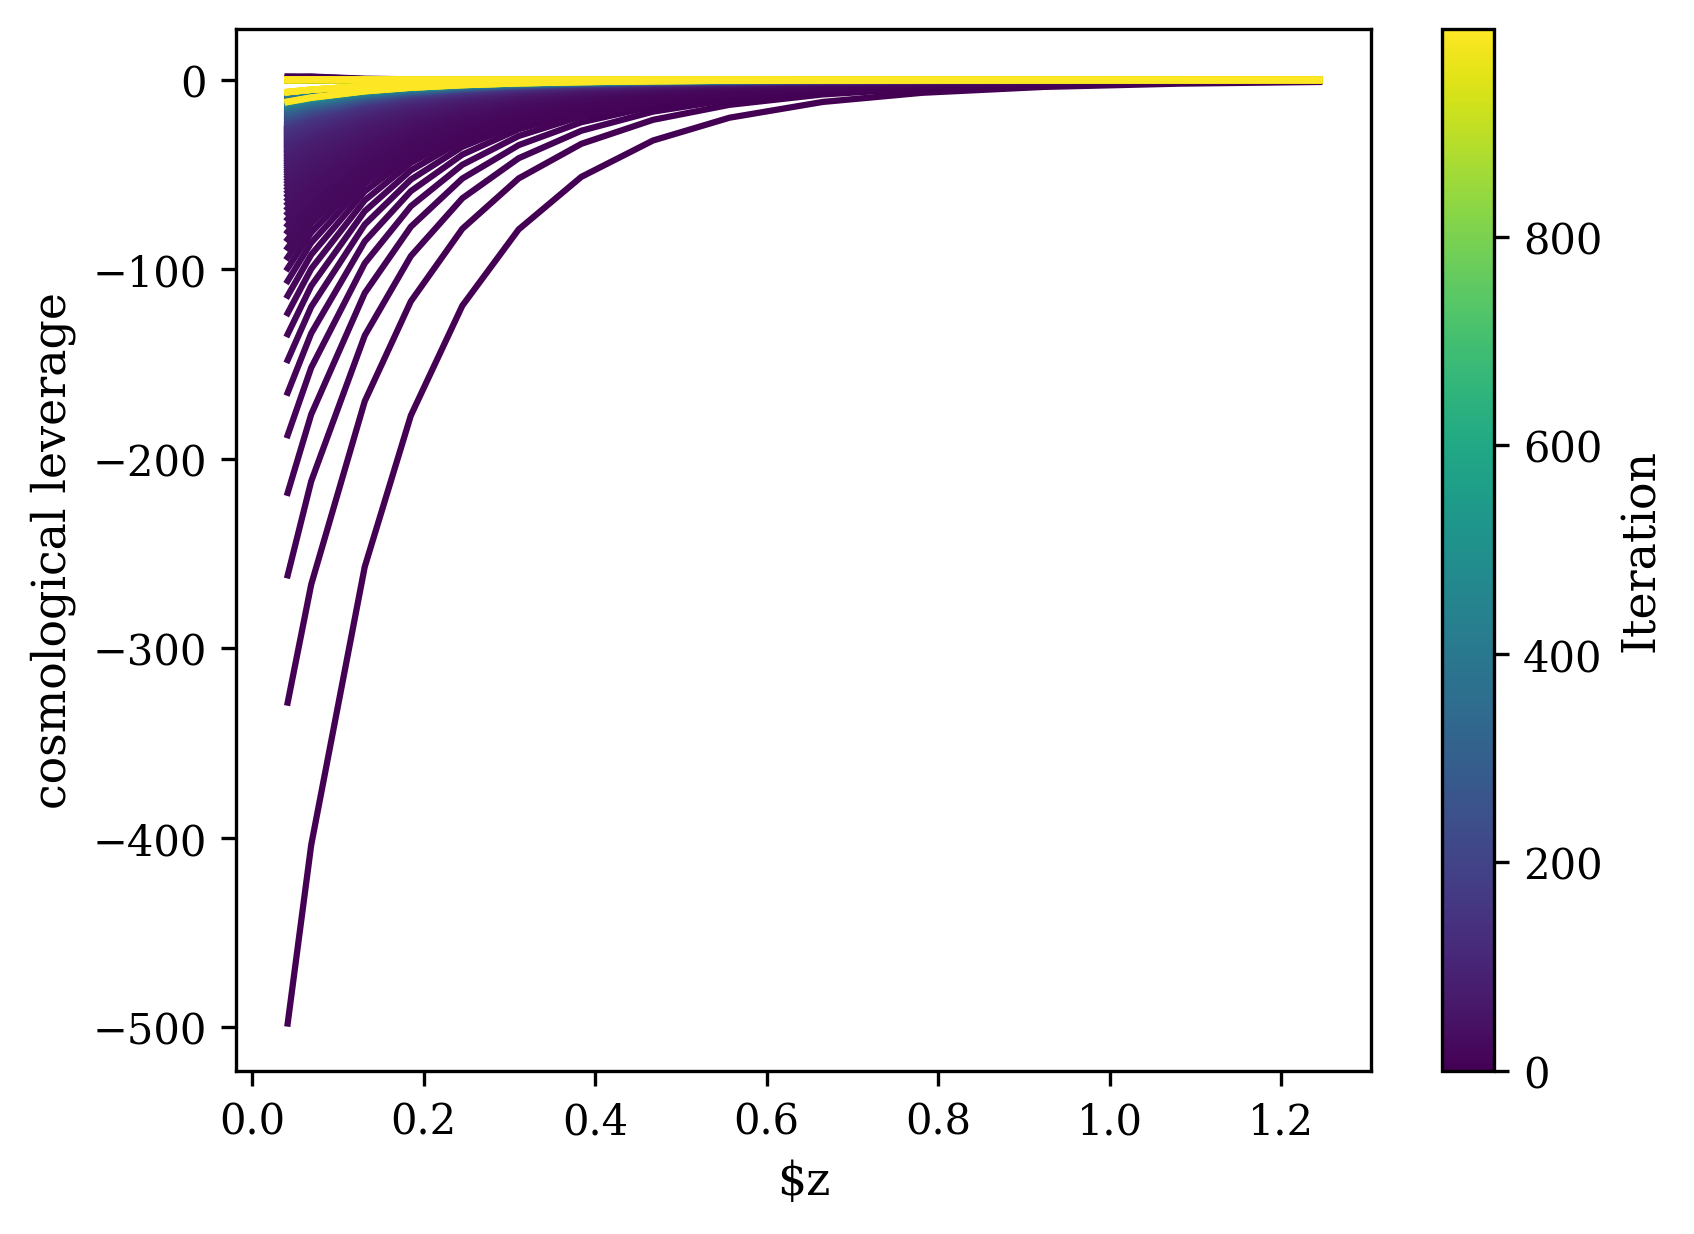

In [76]:
cmap = plt.cm.viridis  # choose any colormap you like
norm = plt.Normalize(vmin=0, vmax=nb_iter-1)

for ii in range(track_Cov.shape[0]):
    plt.plot(z_lsst, track_dFOM[ii],
                color=cmap(norm(ii)))

plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),
             label='Iteration')

plt.xlabel(r'$z')
plt.ylabel('cosmological leverage')

Text(0, 0.5, 'kk')

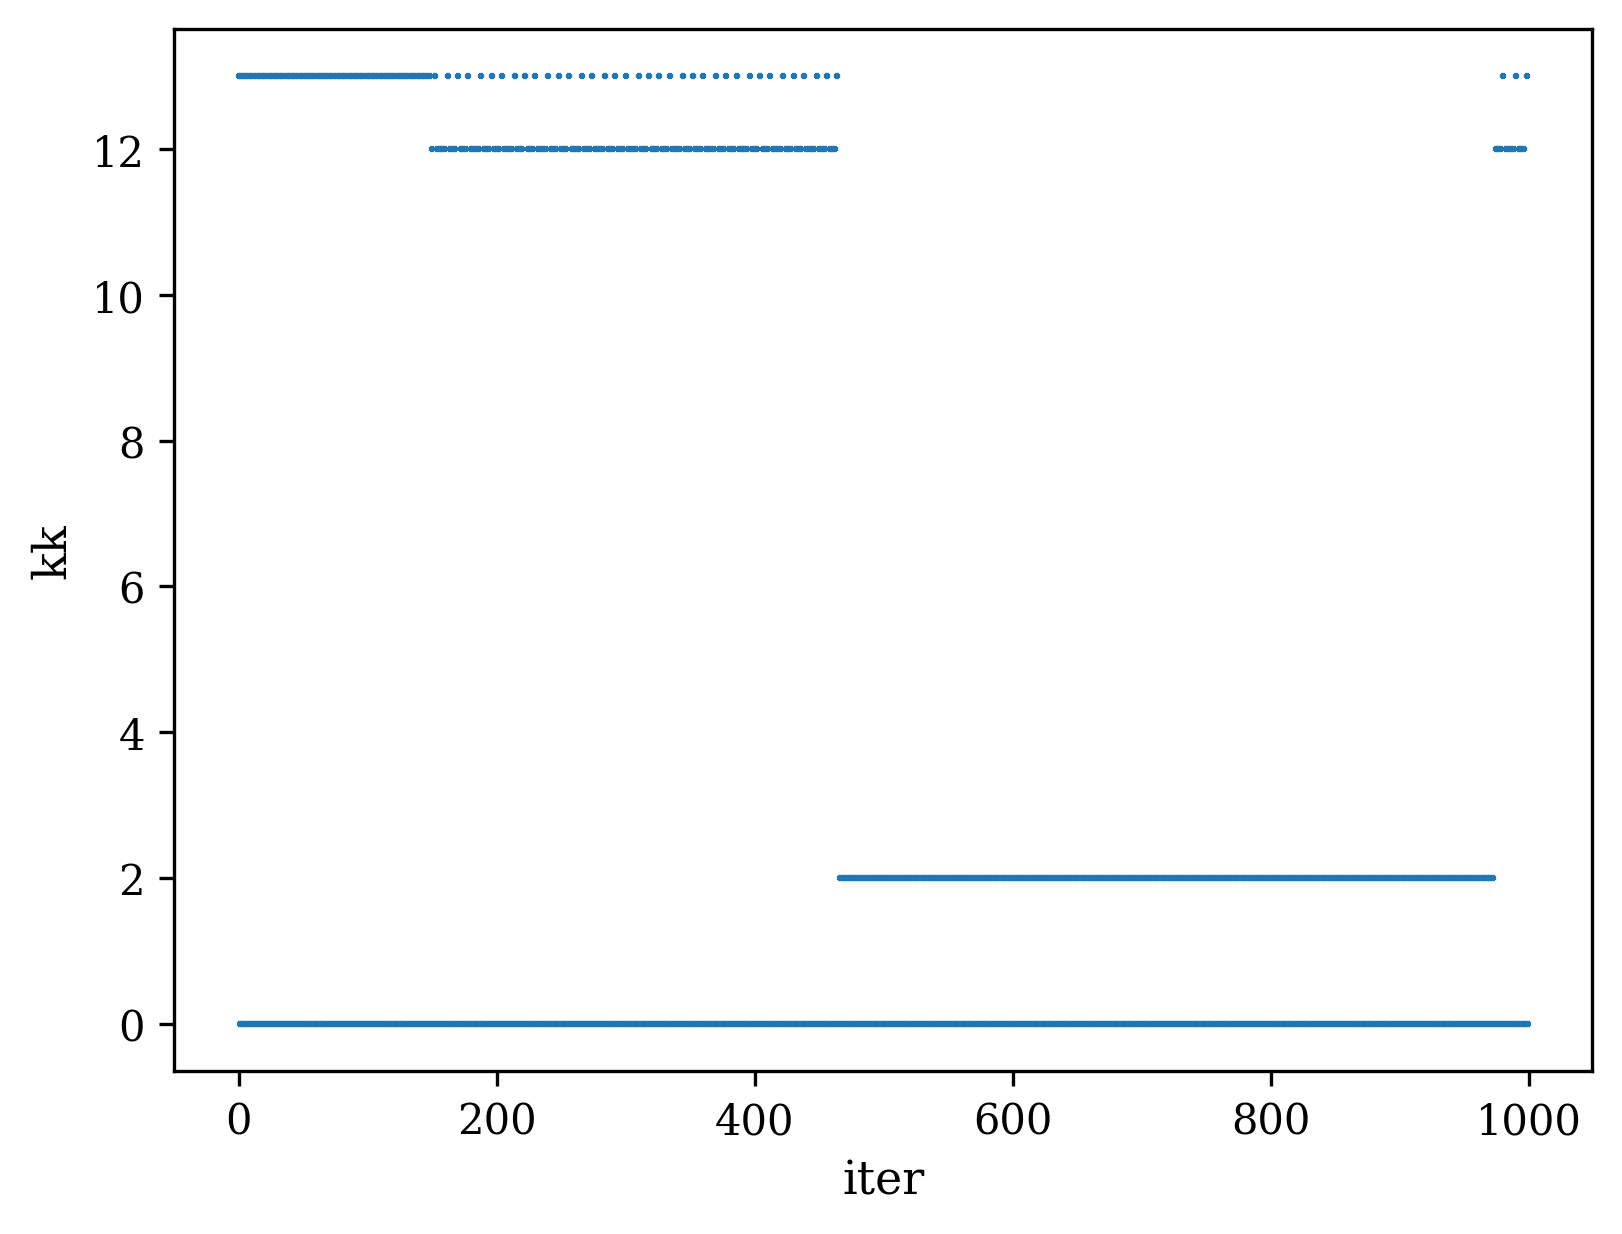

In [94]:
plt.scatter(np.arange(0,nb_iter,1),track_kk,marker='+',s=1)
plt.xlabel('iter')
plt.ylabel('kk')

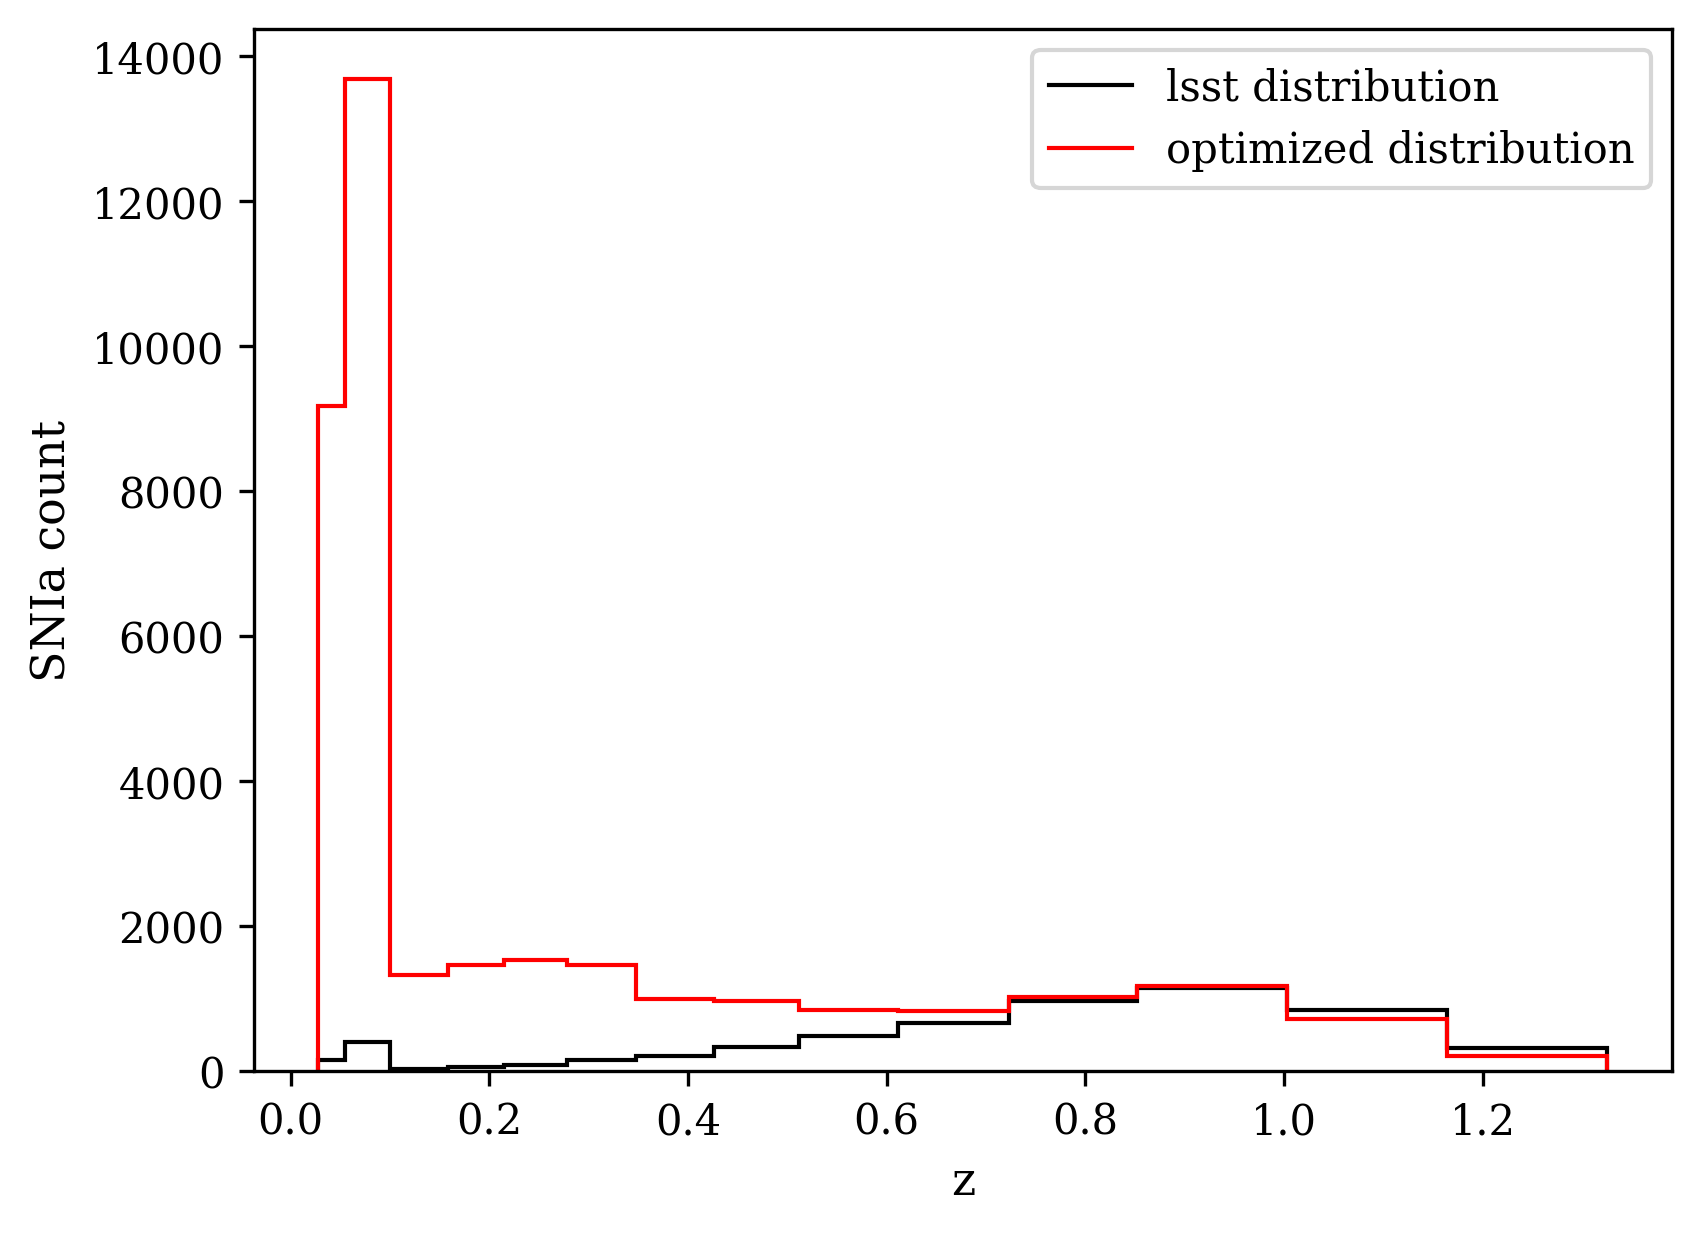

In [78]:
# plot
plt.stairs(dist_lsst, z_edges, label="lsst distribution", color="black")
#plt.stairs(dist_lsst_fake, z_edges, label="lsst fake distribution", color="black")
plt.stairs(track_distribution[-1], z_edges, label='optimized distribution', color='red')
plt.xlabel("z")
plt.ylabel("SNIa count")
plt.legend(loc='upper right')
plt.savefig('figures/dist_comparison_lsst_1000')
plt.show()

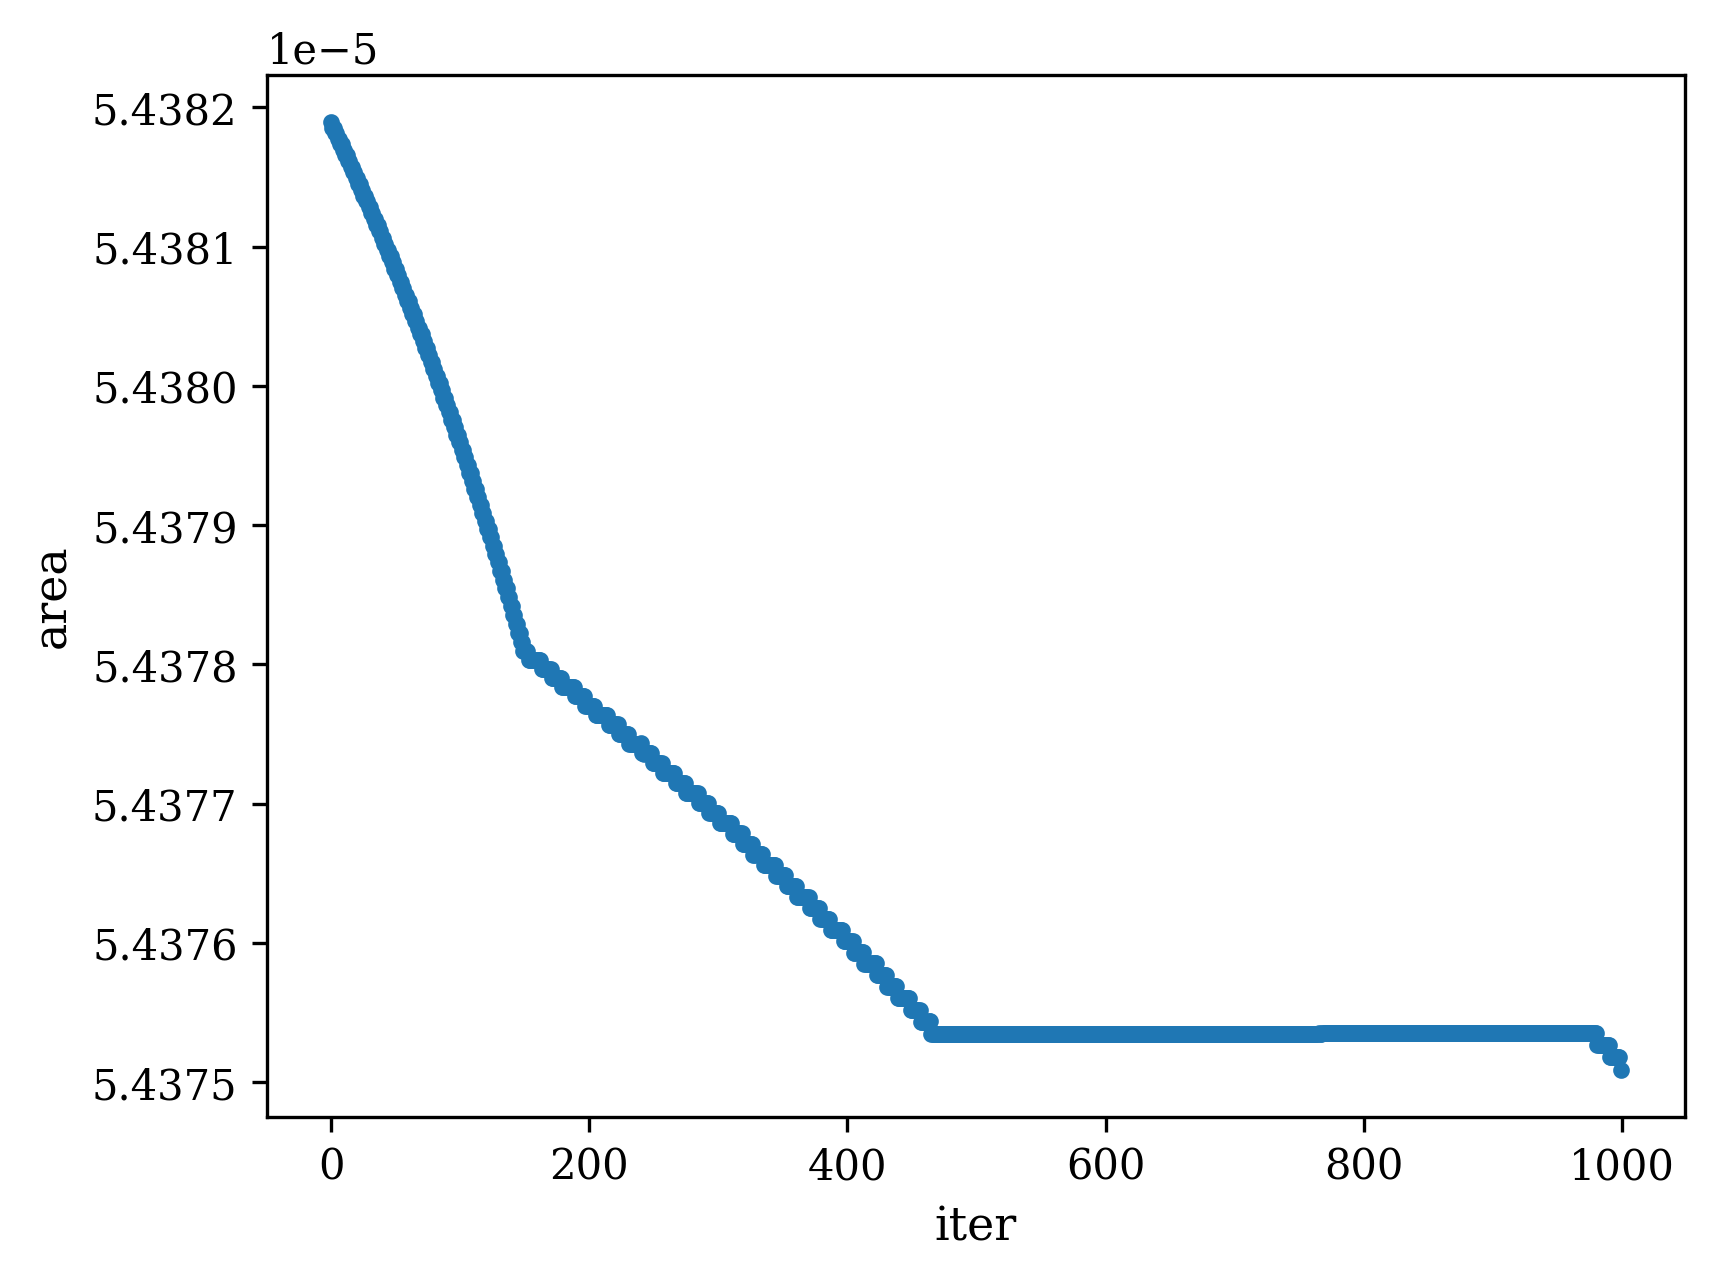

In [79]:
plt.plot(track_ellipse[:,3], marker='.')
plt.xlabel('iter')
plt.ylabel('area')
plt.savefig('figures/track_area_lsst_1000')

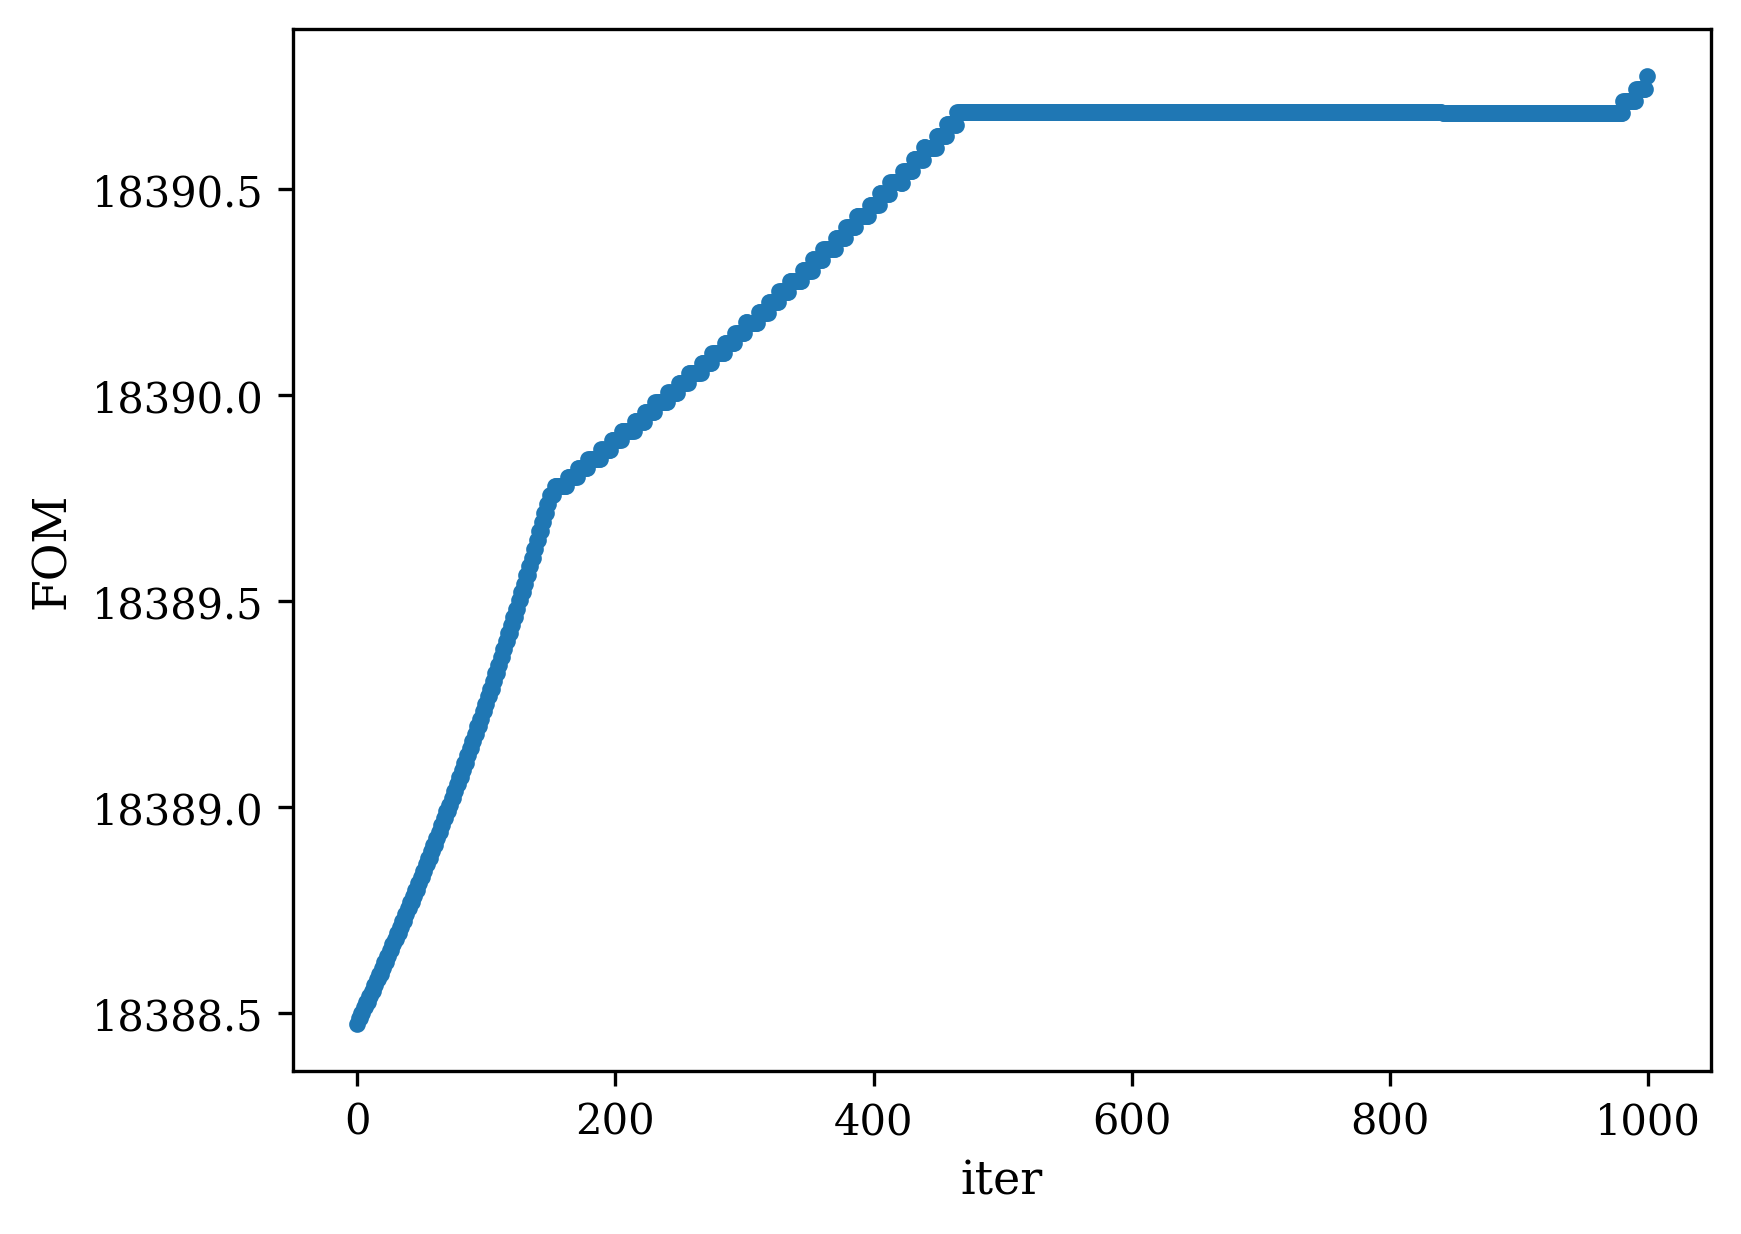

In [80]:
plt.plot(1/track_ellipse[:,3], marker='.')
plt.xlabel('iter')
plt.ylabel('FOM')
plt.savefig('figures/track_fom_lsst_1000')

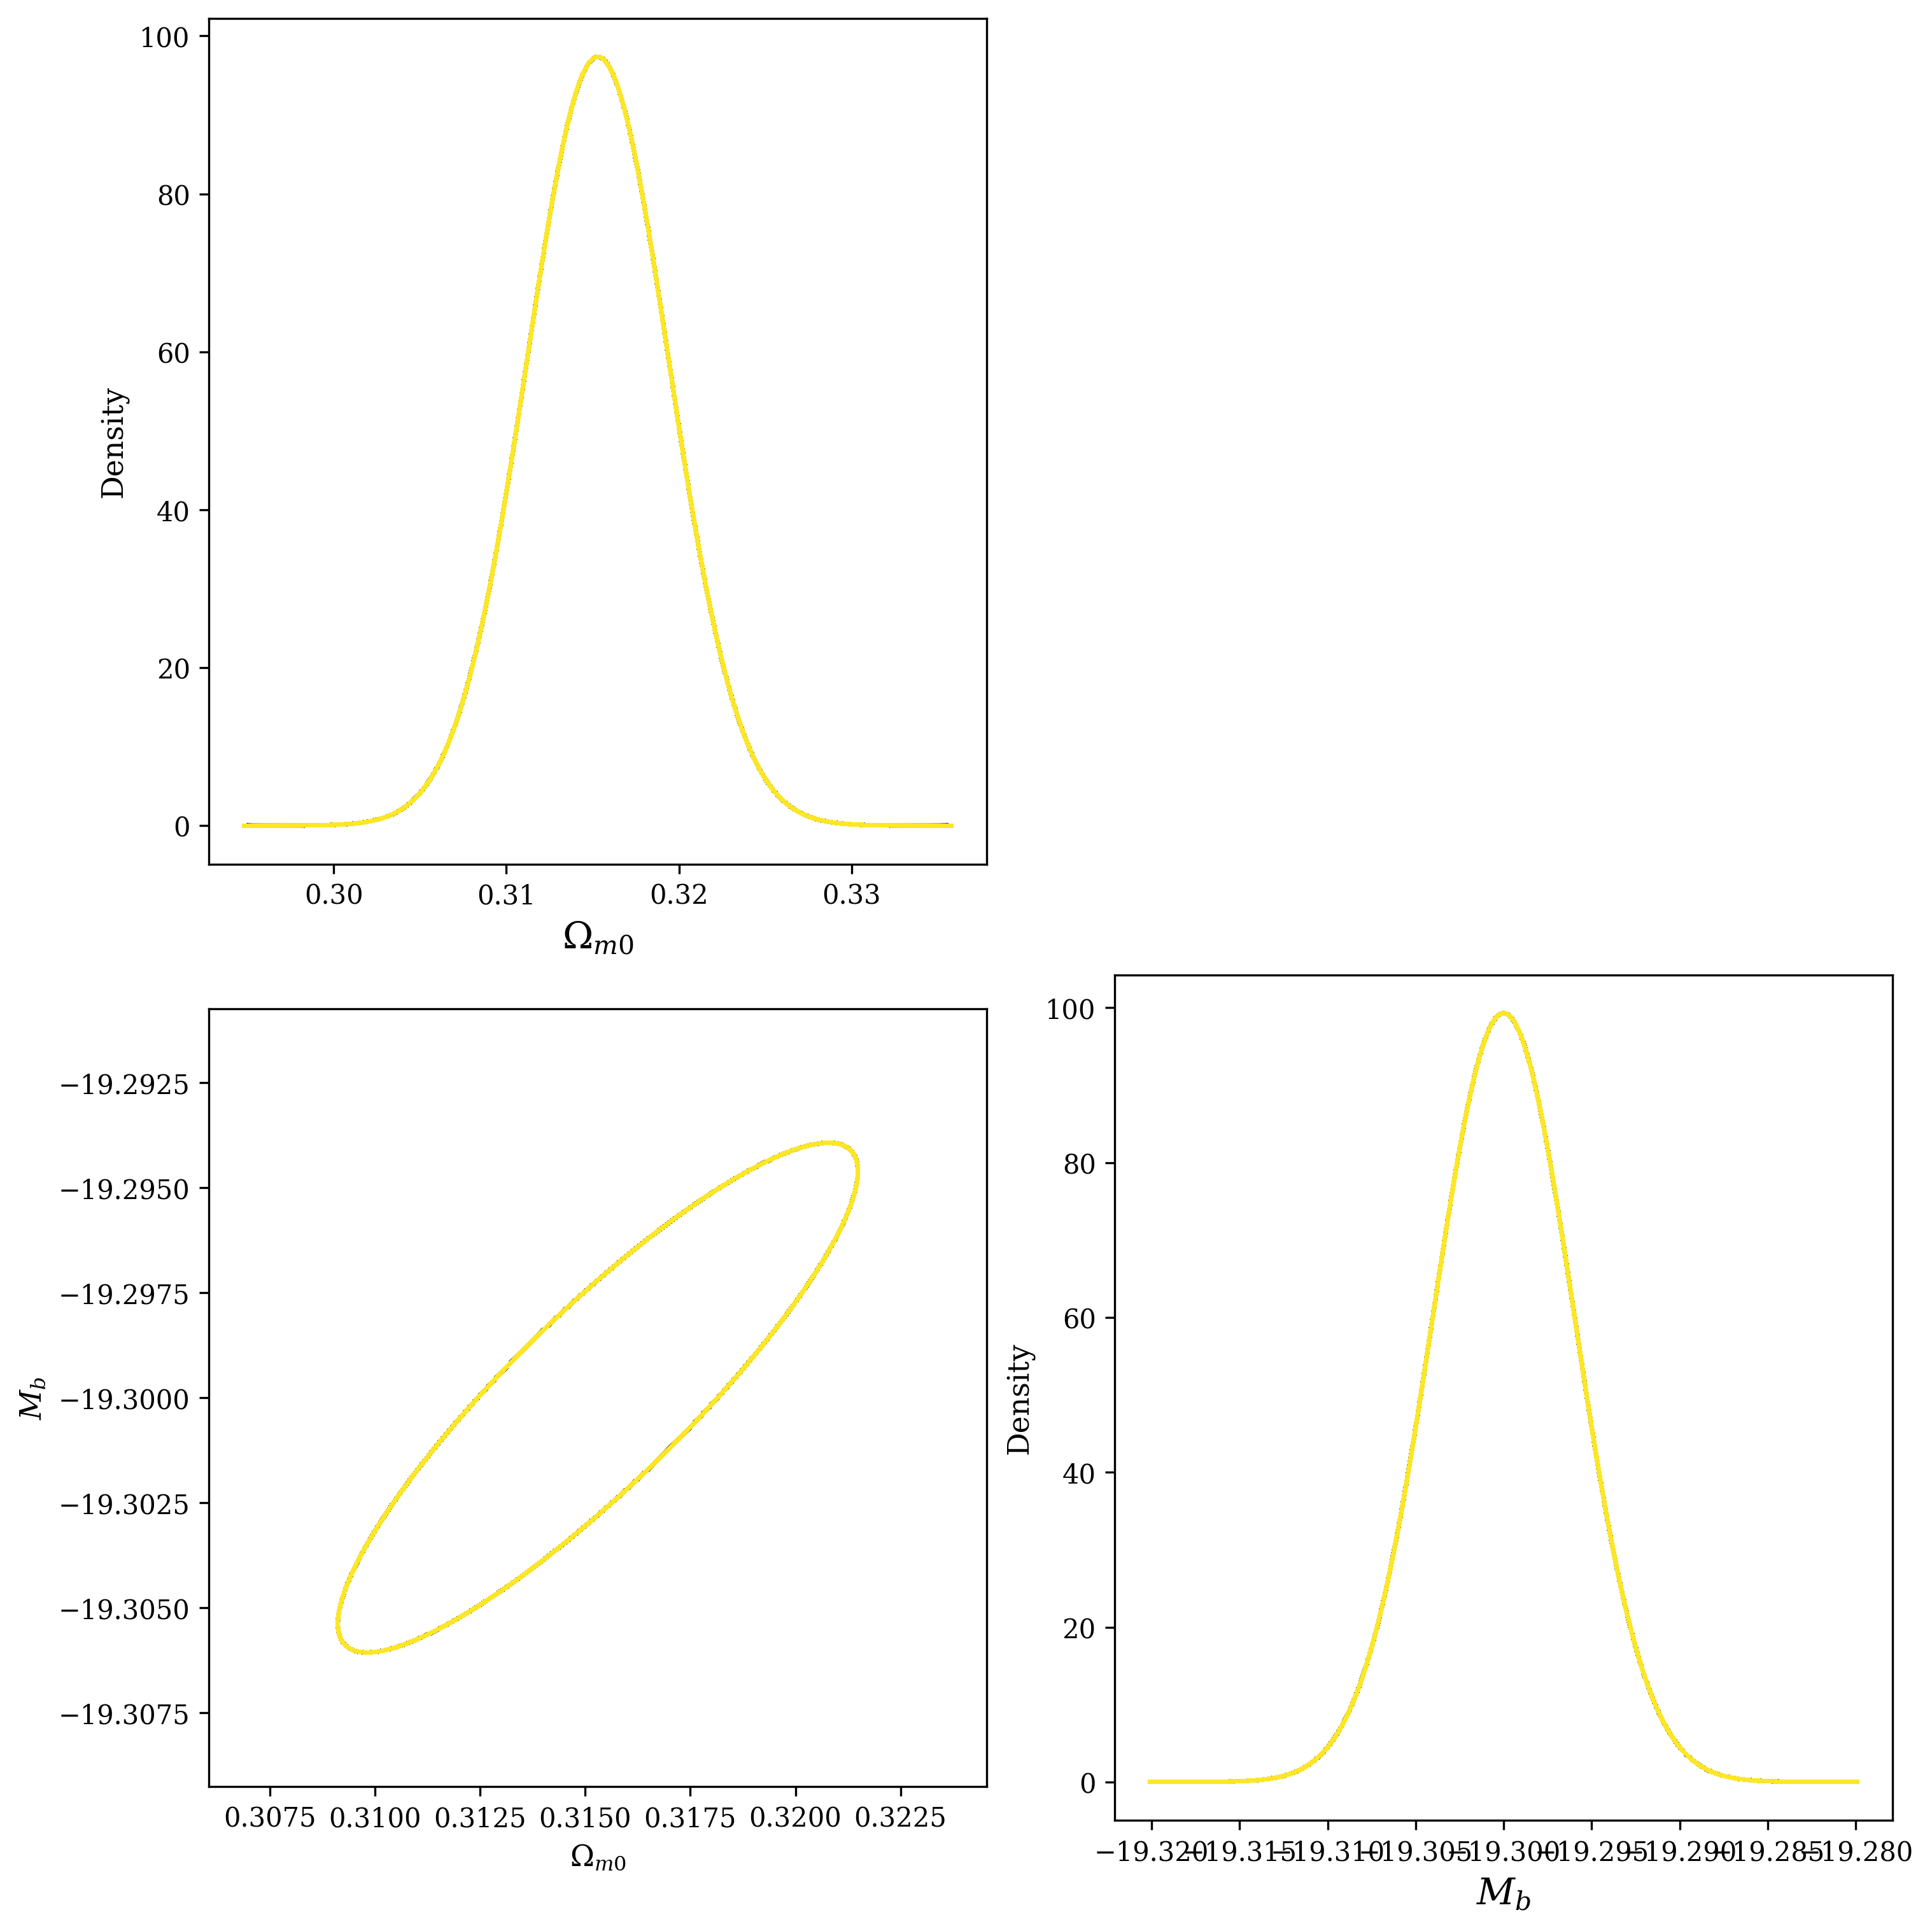

In [81]:
param_names = ['Om0', 'Mb']
param_labels = [r'$\Omega_{m0}$', r'$M_b$']
param_to_plot = ['Om0',  'Mb']
fiducial_param = [Om0_fLCDM, Mb_fid]

N = len(track_FF)  
cmap = cm.viridis  
clrs = cmap(np.linspace(0, 1, N))

fig, _, axs_2d, axs_1d, param_indices = fma.create_fisher_plot(
    param_names, param_to_plot, param_labels, figsize=10
)

for i, fisher_matrix in enumerate(track_FF):
    color = clrs[i]
    fma.add_fisher_to_plot(
        fisher_matrix,
        fiducial_param=fiducial_param,
        axs_2d=axs_2d,
        axs_1d=axs_1d,
        param_indices=param_indices,
        alpha_values=[0.32],
        color=color,
        filled=False,
        param_labels=param_labels
    )


# fma.add_fisher_to_plot(
#         FF,
#         fiducial_param=[w0_fCPL, wa_fCPL],
#         axs_2d=axs_2d,
#         axs_1d=axs_1d,
#         param_indices=param_indices,
#         alpha_values=[0.32],
#         color='blue',
#         filled=False,
#         param_labels=param_labels
#     )

#plt.savefig('figures/track_ellipses_lsst_1000')

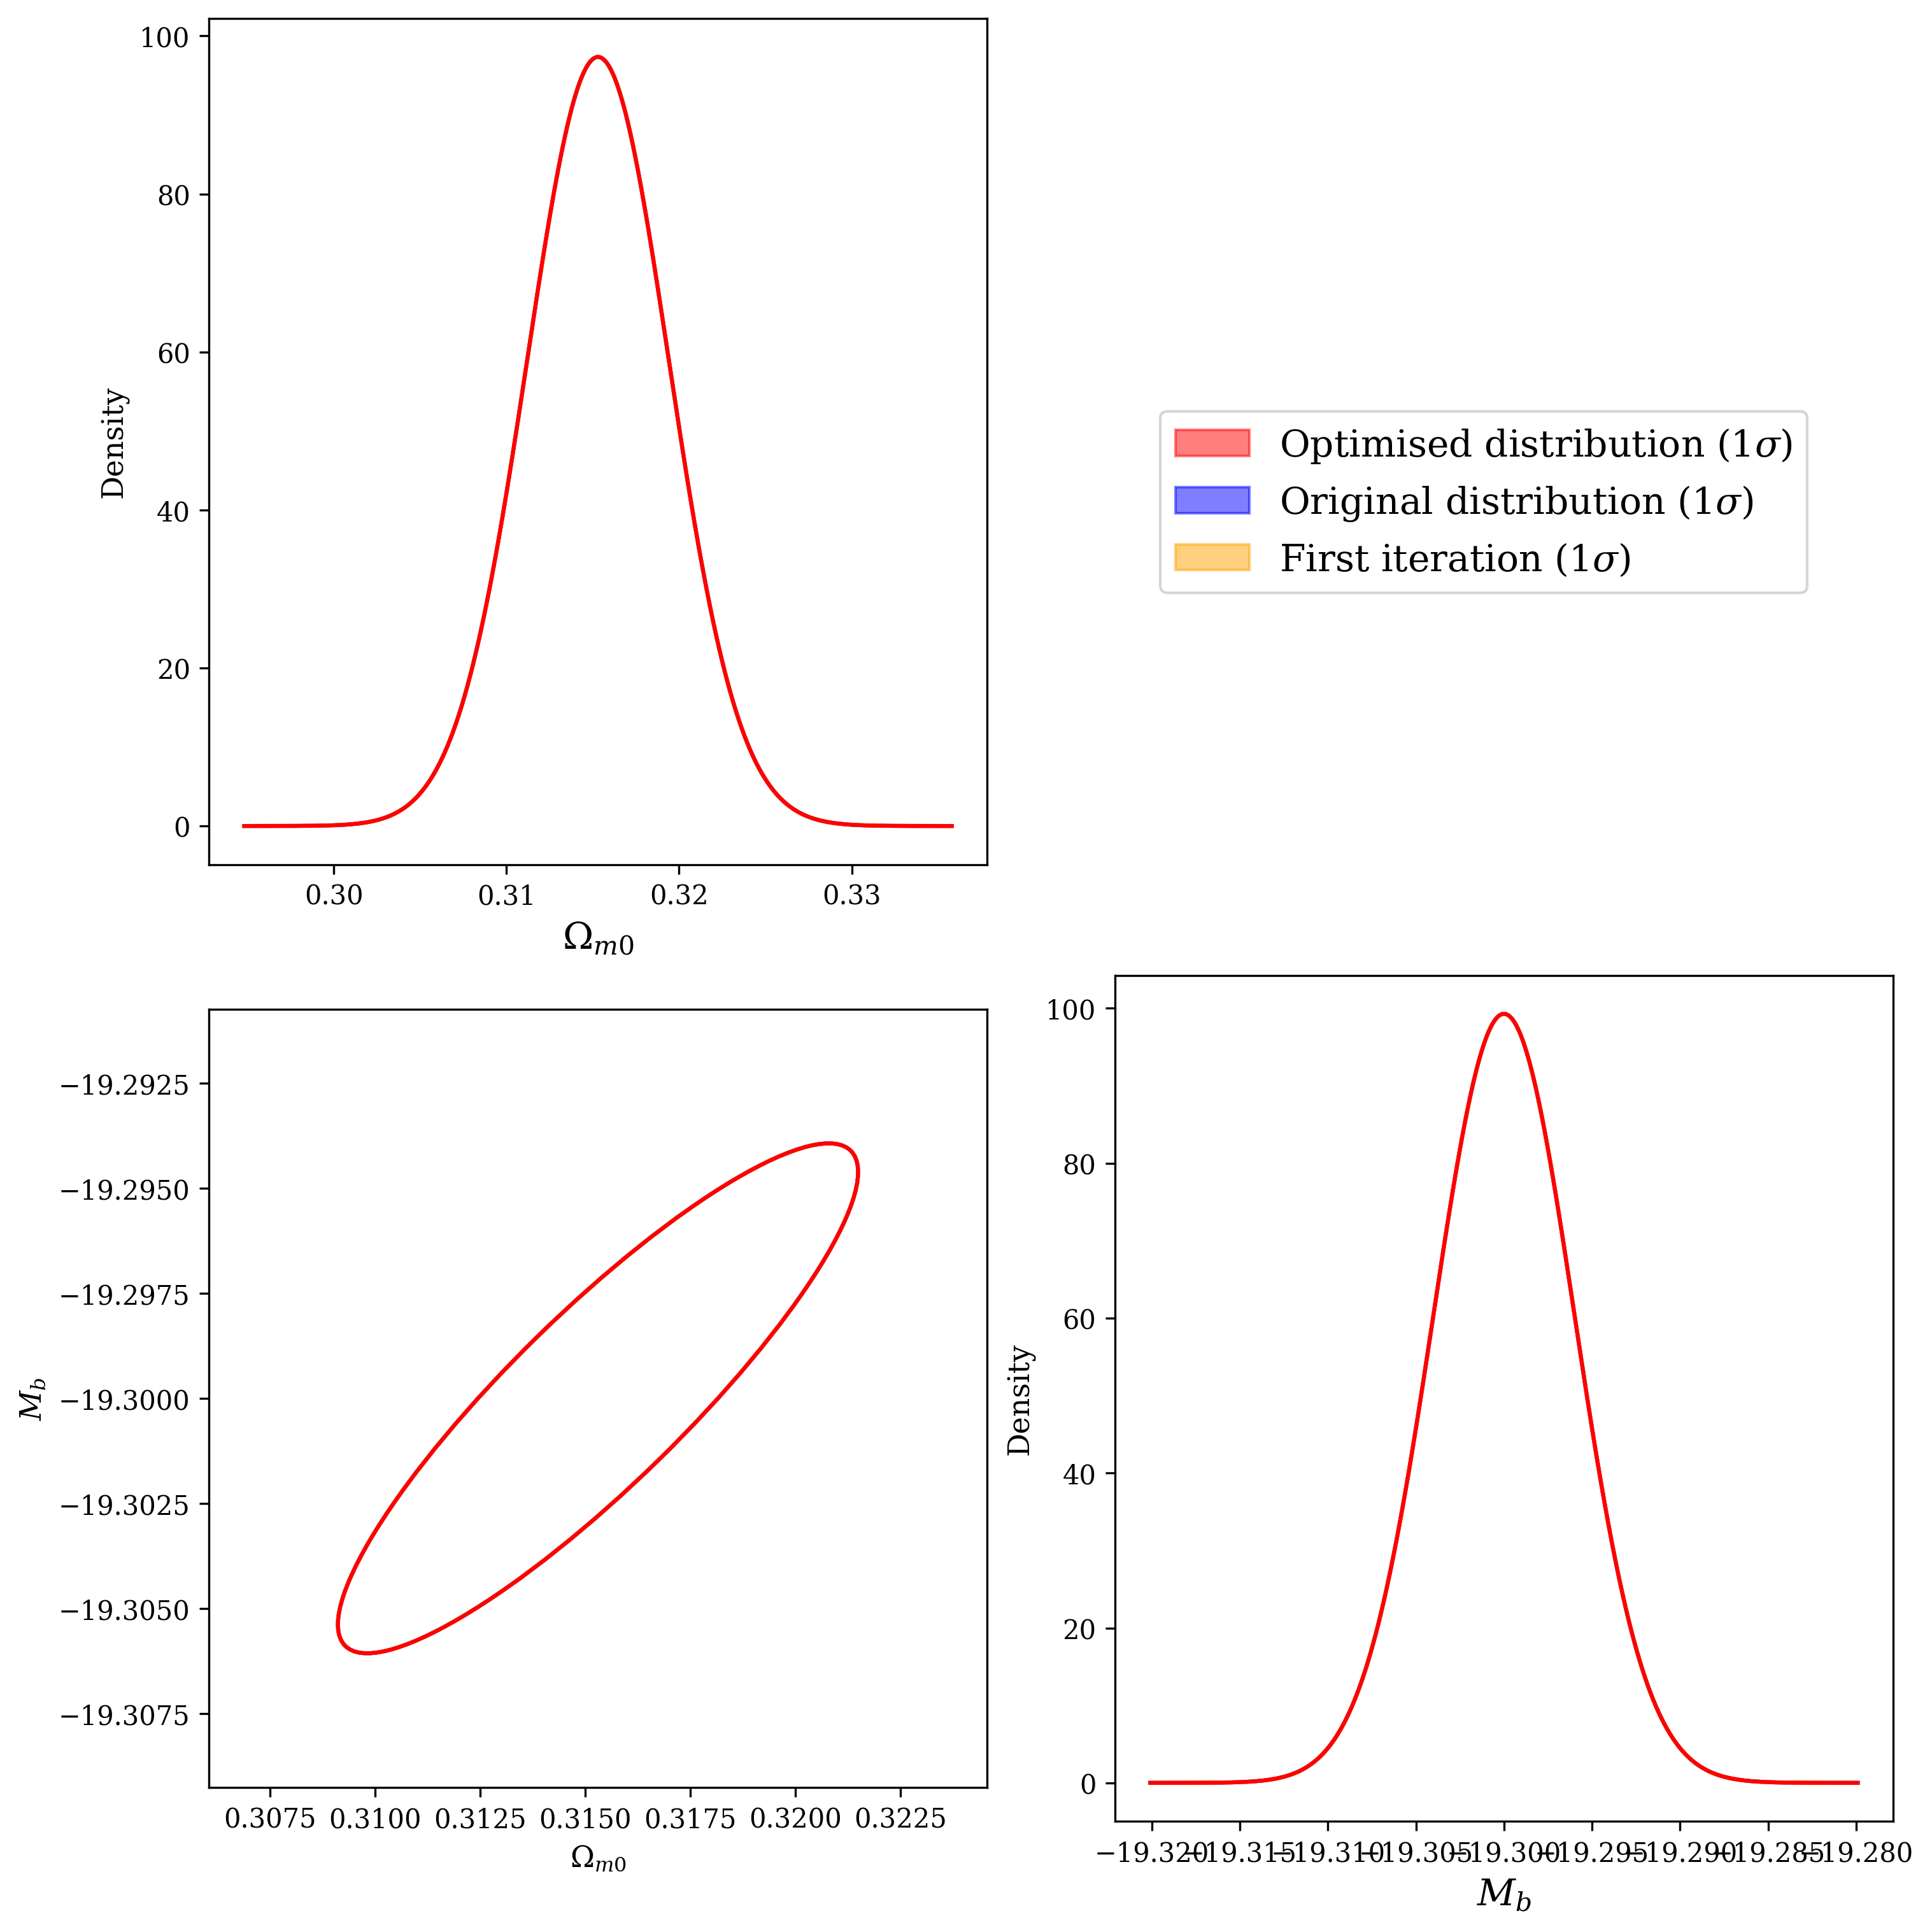

In [82]:
fig, _, axs_2d, axs_1d, param_indices = fma.create_fisher_plot(
    param_names, param_to_plot, param_labels, figsize=10
)
# original fisher matrix
fma.add_fisher_to_plot(
        FF,
        fiducial_param=fiducial_param,
        axs_2d=axs_2d,
        axs_1d=axs_1d,
        param_indices=param_indices,
        alpha_values=[0.32],
        color='blue',
        filled=False,
        param_labels=param_labels
    )

fma.add_fisher_to_plot(
        track_FF[0],
        fiducial_param=fiducial_param,
        axs_2d=axs_2d,
        axs_1d=axs_1d,
        param_indices=param_indices,
        alpha_values=[0.32],
        color='orange',
        filled=False,
        param_labels=param_labels
    )
fma.add_fisher_to_plot(
        track_FF[-1],
        fiducial_param=fiducial_param,
        axs_2d=axs_2d,
        axs_1d=axs_1d,
        param_indices=param_indices,
        alpha_values=[0.32],
        color='red',
        filled=False,
        param_labels=param_labels
    )

# Manually add a custom legend for confidence levels and datasets
legend_elements = [
    Patch(facecolor='red', edgecolor='red', alpha=0.5, label=r'Optimised distribution (1$\sigma$)'),
    Patch(facecolor='blue', edgecolor='blue', alpha=0.5, label=r'Original distribution (1$\sigma$)'),
    Patch(facecolor='orange', edgecolor='orange', alpha=0.5, label=r'First iteration (1$\sigma$)')]

fig.legend(handles=legend_elements,bbox_to_anchor=(0.95, 0.8), fontsize=14)
plt.savefig('figures/ellispes_comparison_lsst_1000')
# Show the final overlaid plot
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


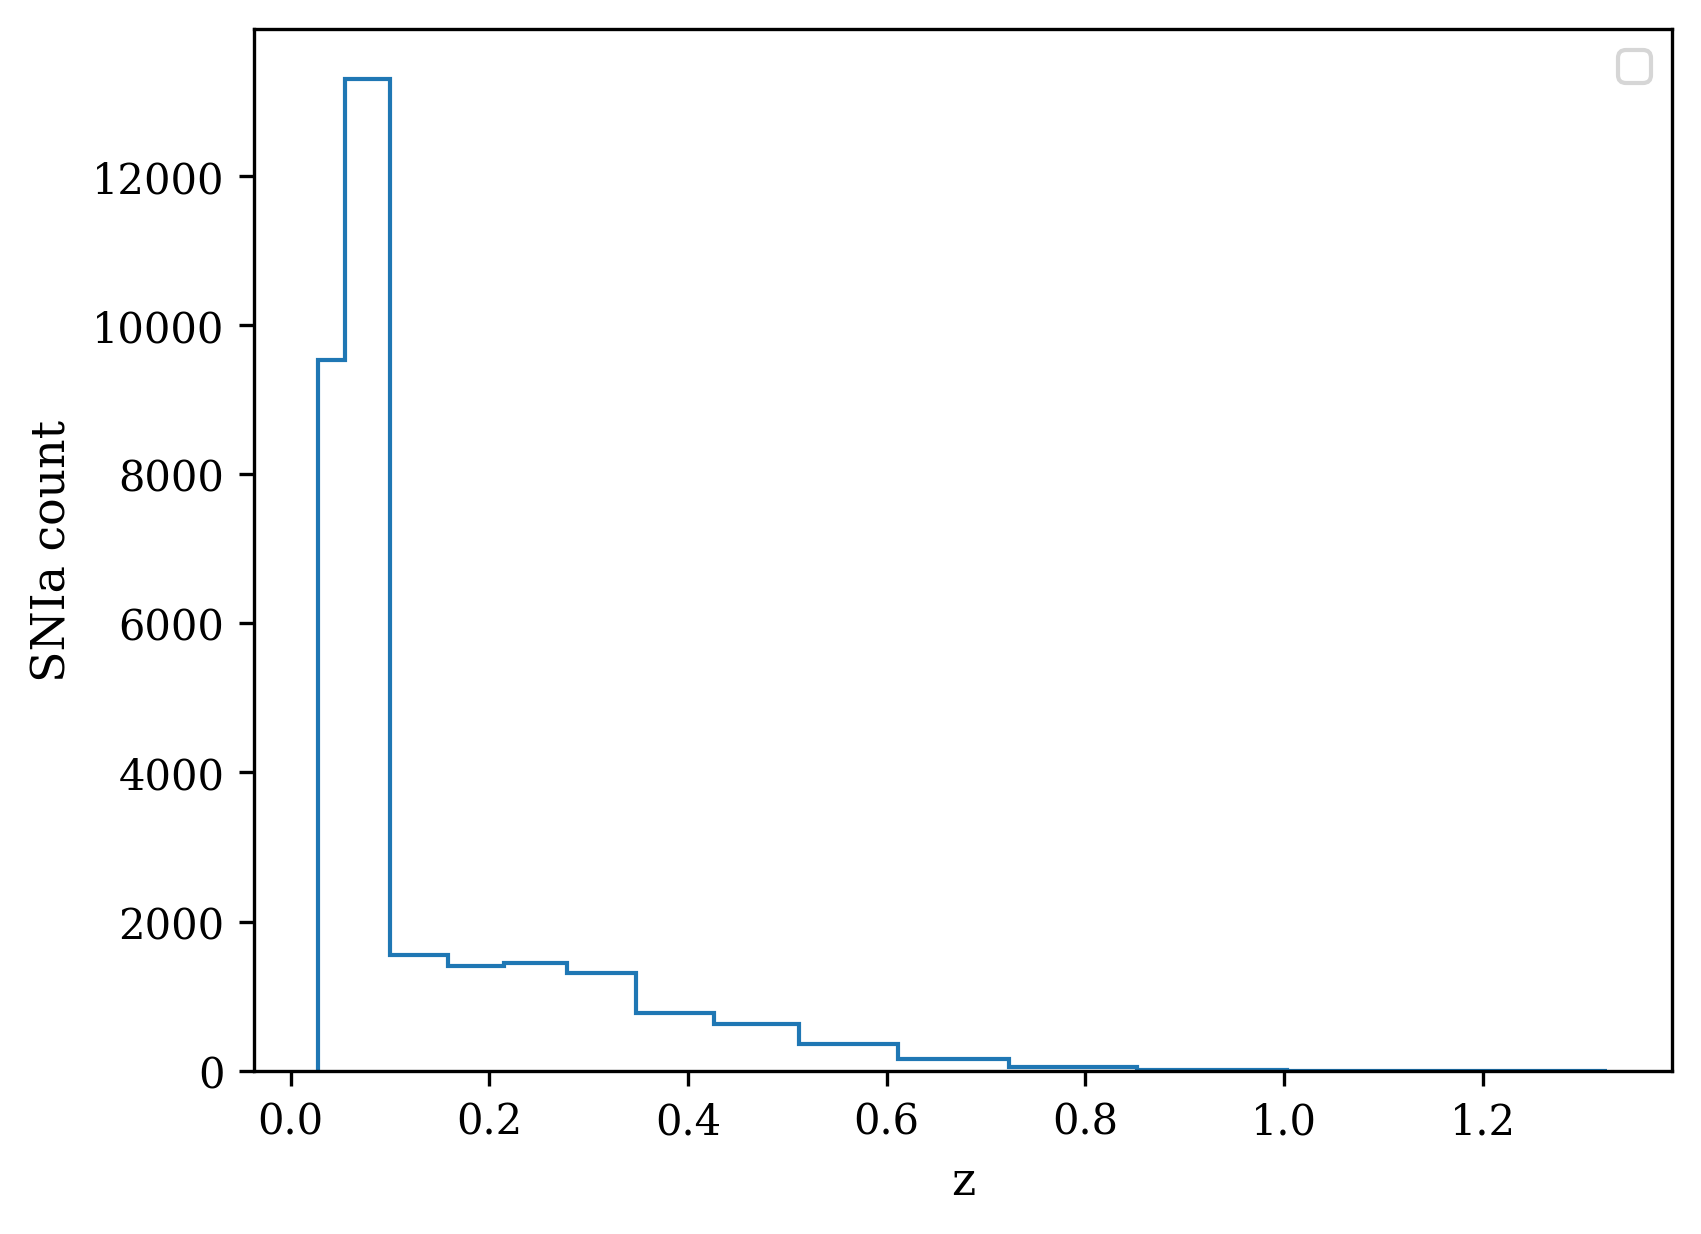

In [83]:
# plot

plt.stairs(track_delta_n.sum(axis=0), z_edges)
plt.xlabel("z")
plt.ylabel("SNIa count")
plt.legend(loc='upper right')
plt.show()

In [84]:
for cc in track_Cov:
    print(fma.is_positive_definite(cc))

True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True
True


In [85]:
np.diag(Cov_lsst)

array([1.393461e-04, 6.859810e-05, 4.629661e-04, 2.222844e-04,
       1.488824e-04, 8.127840e-05, 6.774840e-05, 4.108410e-05,
       3.615410e-05, 2.890440e-05, 3.372610e-05, 3.827040e-05,
       6.277250e-05, 2.016069e-04])

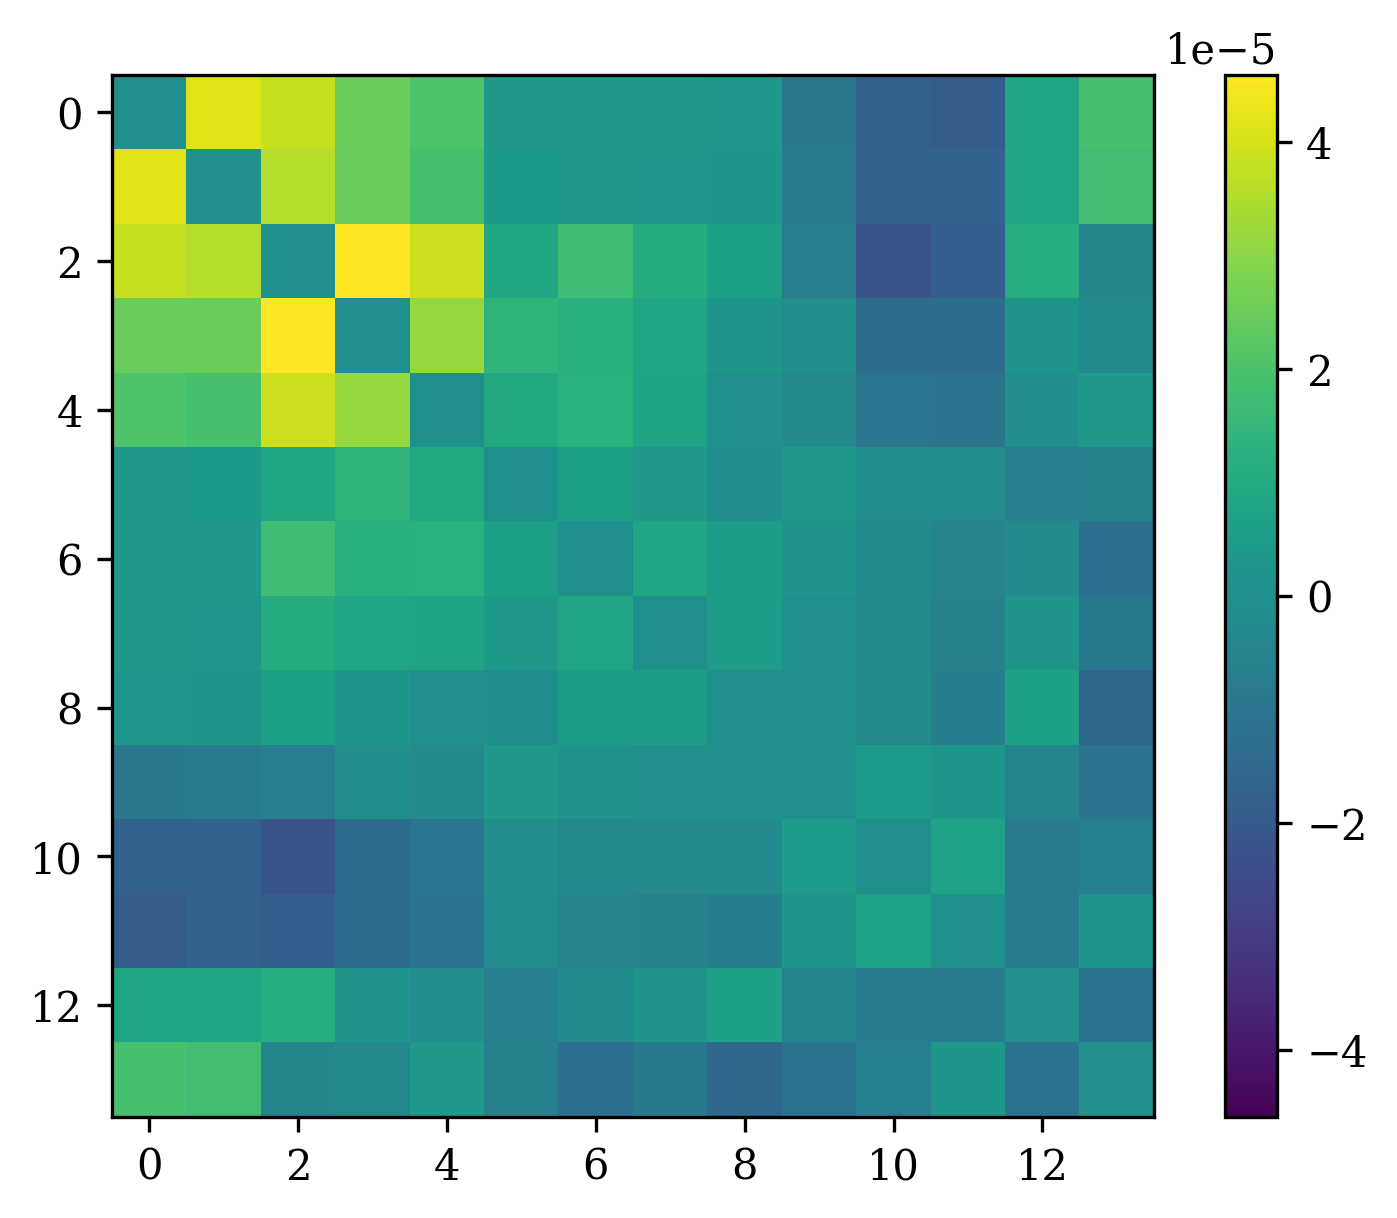

In [86]:
cc_sys = Cov_lsst-np.diag(np.diag(Cov_lsst))
vmin=np.min(cc_sys)
vmax=np.max(cc_sys)
norm = colors.Normalize(vmin=-max(np.abs(vmin),np.abs(vmax)), 
                        vmax=max(np.abs(vmin),np.abs(vmax)))

plt.imshow(cc_sys,norm=norm)

plt.colorbar()

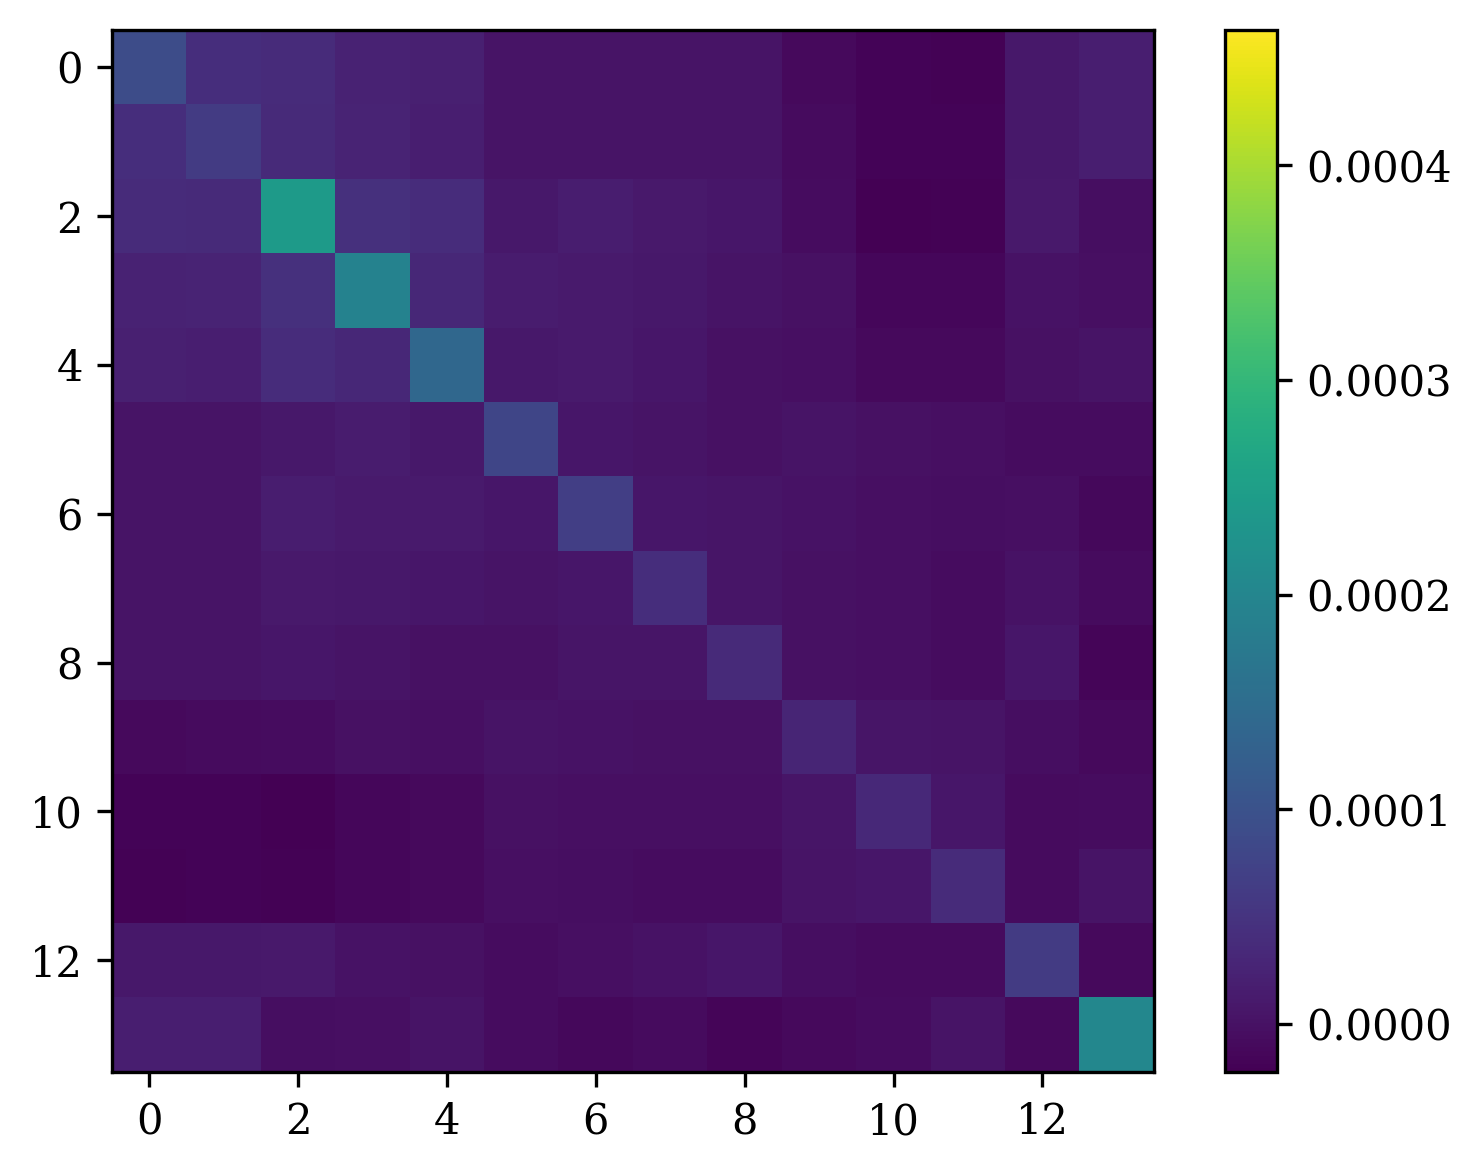

In [87]:
Cov_lsst1 = track_Cov[0]
Cov_lsst2 = track_Cov[1]

norm = colors.Normalize(vmin=np.min(Cov_lsst), vmax=np.max(Cov_lsst))

plt.imshow(Cov_lsst1,norm=norm)
plt.colorbar()